# Notebook 2 - Scarcity Regimes and System Tightness

## Objective

This notebook examines the conditions associated with extreme electricity prices in Alberta.

Notebook 1 provided an overview of Alberta's electricity market and how it evolved from 2015 to 2025. Here, the focus shifts to periods of system stress. The analysis looks at whether high-price hours tend to coincide with tight capacity and supply margins, reduced thermal headroom, generation outages, greater reliance on imports, or combinations of these conditions.

Price thresholds are used to identify increasingly severe market outcomes and compare the physical conditions surrounding them. A high price does not, by itself, imply physical scarcity.

The results are descriptive and based on contemporaneous market conditions. They are intended to characterize scarcity regimes, not to establish causality or forecasting performance.

> An important distinction is made between installed capacity and available capacity. Installed capacity describes the reported size of the generation fleet, while available capacity reflects the supply reported as available in a given hour. Neither is the same as operating reserve, so the margin measures used in this notebook are best understood as indicators of system tightness rather than official reserve measures.

## 1. Imports and Data Validation

### 1.1 Imports and canonical dataset

The notebook uses the canonical hourly master dataset produced by the project pipeline. Notebook-specific variables are stored separately in scarcity_features.

The study period covers Alberta operating years 2015–2025.

In [1]:
# ---------------------------------------------------------------------
# Configure project imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path: 
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)

np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f"Canonical master loaded: "
    f"{master.shape[0]:,} rows × {master.shape[1]:,} columns"
)

Canonical master loaded: 100,033 rows × 619 columns


### 1.2 Coverage

Timestamp integrity, annual coverage, required columns, and missingness in the principal Notebook 2 variables are checked before any scarcity features are constructed.

Missing intertie observations are retained as missing rather than interpreted as zero imports. Technology-level availability field are also treated cautiously because AESO technology classifications and reporting boundaries changed during the study period. 

In [2]:
# ---------------------------------------------------------------------
# Validate Notebook 2 Inputs, Coverage, and Reporting Boundaries
# ---------------------------------------------------------------------

STUDY_START_YEAR, STUDY_END_YEAR = 2015, 2025
ALBERTA_TIMEZONE = "America/Edmonton"
PRICE_THRESHOLDS = [100, 300, 500, 900]
PRIMARY_SCARCITY_THRESHOLD = 500

THERMAL_TECHNOLOGIES = ["coal", "cogeneration", "combined_cycle", "dual_fuel", "gas_fired_steam", "simple_cycle"]
THERMAL_AVAILABILITY_COLUMNS = [f"{t}_system_available" for t in THERMAL_TECHNOLOGIES]
THERMAL_GENERATION_COLUMNS = [f"{t}_system_generation" for t in THERMAL_TECHNOLOGIES]

REQUIRED_COLUMNS = [
    "timestamp_utc", "timestamp_alberta", "year_alberta", "pool_price", "ail_mw",
    "total_system_capacity", "total_system_available", "total_system_generation",
    "total_outage_mw", "thermal_outage_mw", "renewable_outage_mw",
    "simple_cycle_outage", "combined_cycle_outage", "cogeneration_outage",
    "total_imports_mw", "total_exports_mw", "net_imports_mw",
    "wind_system_generation", "solar_system_generation",
    "atc_sk_import", "atc_wecc_import", "ttc_sk_import", "ttc_wecc_import",
] + THERMAL_AVAILABILITY_COLUMNS + THERMAL_GENERATION_COLUMNS

AUDIT_COLUMNS = [
    "pool_price", "ail_mw", "total_system_capacity", "total_system_available",
    "total_system_generation", "total_outage_mw", "thermal_outage_mw",
    "net_imports_mw", "wind_system_generation", "solar_system_generation",
    "atc_sk_import", "atc_wecc_import",
]

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(master.columns))
if missing_columns:
    raise ValueError(f"Master dataset is missing Notebook 2 columns: {missing_columns}")

master["timestamp_utc"] = pd.to_datetime(master["timestamp_utc"], utc=True)
master = (
    master.sort_values("timestamp_utc")
    .loc[lambda x: x["year_alberta"].between(STUDY_START_YEAR, STUDY_END_YEAR)]
    .reset_index(drop=True)
)

duplicate_timestamps = int(master["timestamp_utc"].duplicated().sum())
non_hourly_intervals = int(master["timestamp_utc"].diff().iloc[1:].ne(pd.Timedelta(hours=1)).sum())

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        f"Hourly timestamp validation failed: duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

# ---------------------------------------------------------------------
# Build Compact Coverage Audit
# ---------------------------------------------------------------------

study_years = pd.Index(range(STUDY_START_YEAR, STUDY_END_YEAR + 1), name="year_alberta")
observed_hours = master.groupby("year_alberta").size().reindex(study_years, fill_value=0)

expected_hours = pd.Series({
    year: len(pd.date_range(
        f"{year}-01-01", f"{year + 1}-01-01",
        inclusive="left", freq="h", tz=ALBERTA_TIMEZONE,
    ))
    for year in study_years
}, name="expected_hours")

annual_coverage = pd.DataFrame({
    "item": [f"Year {year}" for year in study_years],
    "category": "annual coverage",
    "observed_hours": observed_hours.values,
    "expected_hours": expected_hours.values,
})
annual_coverage["missing_hours"] = annual_coverage["expected_hours"] - annual_coverage["observed_hours"]
annual_coverage["coverage_pct"] = annual_coverage["observed_hours"] / annual_coverage["expected_hours"] * 100

input_coverage = pd.DataFrame({
    "item": AUDIT_COLUMNS,
    "category": "input coverage",
    "missing_hours": master[AUDIT_COLUMNS].isna().sum().values,
    "coverage_pct": master[AUDIT_COLUMNS].notna().mean().mul(100).values,
    "first_reported": [master.loc[master[c].notna(), "timestamp_alberta"].min() for c in AUDIT_COLUMNS],
    "last_reported": [master.loc[master[c].notna(), "timestamp_alberta"].max() for c in AUDIT_COLUMNS],
})

solar = master["solar_system_generation"]
solar_reported = solar.notna()
solar_first_reported = master.loc[solar_reported, "timestamp_alberta"].min()
solar_missing_before = solar.isna() & master["timestamp_alberta"].lt(solar_first_reported)
solar_missing_after = solar.isna() & master["timestamp_alberta"].ge(solar_first_reported)

if solar_missing_after.any() or solar_missing_before.sum() != solar.isna().sum():
    raise ValueError("Solar missingness does not match the expected reporting boundary.")

solar_audit = pd.DataFrame([{
    "item": "Solar reporting boundary",
    "category": "reporting boundary",
    "missing_hours": int(solar.isna().sum()),
    "coverage_pct": solar.notna().mean() * 100,
    "first_reported": solar_first_reported,
    "last_reported": master.loc[solar_reported, "timestamp_alberta"].max(),
    "missing_before_reporting": int(solar_missing_before.sum()),
    "missing_after_reporting": int(solar_missing_after.sum()),
}])

audit_summary = pd.concat([annual_coverage, input_coverage, solar_audit], ignore_index=True)

# ---------------------------------------------------------------------
# Display Single Audit Output
# ---------------------------------------------------------------------

display(
    audit_summary[[
        "category", "item", "observed_hours", "expected_hours",
        "missing_hours", "coverage_pct", "first_reported", "last_reported",
        "missing_before_reporting", "missing_after_reporting",
    ]]
    .round({"coverage_pct": 2})
)

,category,item,observed_hours,expected_hours,missing_hours,coverage_pct,first_reported,last_reported,missing_before_reporting,missing_after_reporting
0,annual coverage,Year 2015,8760.0,8760.0,0,100.00,NaT,NaT,NaN,NaN
1,annual coverage,Year 2016,8784.0,8784.0,0,100.00,NaT,NaT,NaN,NaN
2,annual coverage,Year 2017,8760.0,8760.0,0,100.00,NaT,NaT,NaN,NaN
3,annual coverage,Year 2018,8760.0,8760.0,0,100.00,NaT,NaT,NaN,NaN
4,annual coverage,Year 2019,8760.0,8760.0,0,100.00,NaT,NaT,NaN,NaN
5,annual coverage,Year 2020,8784.0,8784.0,0,100.00,NaT,NaT,NaN,NaN
6,annual coverage,Year 2021,8760.0,8760.0,0,100.00,NaT,NaT,NaN,NaN
7,annual coverage,Year 2022,8760.0,8760.0,0,100.00,NaT,NaT,NaN,NaN
8,annual coverage,Year 2023,8760.0,8760.0,0,100.00,NaT,NaT,NaN,NaN
9,annual coverage,Year 2024,8784.0,8784.0,0,100.00,NaT,NaT,NaN,NaN


#### Coverage

Net imports are available through July 2025, so analyses using realized imports exclude the final five months of 2025. Solar generation reporting begins on December 5, 2017; all missing solar observations occur before this reporting boundary, with no gaps afterward. Treating pre-reporting solar generation as zero is reasonable for historical net-load construction.

### 1.3 Structural market regimes

Alberta’s generation mix changed considerably between 2015 and 2025, so some relationships may differ across periods. To account for this, the analysis uses four broad market regimes based on the transition documented in Notebook 1:

- **2015–2017:** coal-dominant system
- **2018–2021:** coal-to-gas transition
- **2022–2024:** late coal exit and renewable buildout
- **2025:** coal-free gas-renewable system

These periods are defined by changes in the generation mix, not by price outcomes.

In [3]:
# ---------------------------------------------------------------------
# Structural Generation Regimes
# ---------------------------------------------------------------------

STRUCTURAL_REGIME_ORDER = [
    "Coal-dominant", "Coal-to-gas transition",
    "Late coal exit and renewable buildout", "Coal-free gas-renewable system",
]

structural_regime = pd.Categorical(
    np.select(
        [master["year_alberta"].le(2017), master["year_alberta"].le(2021), master["year_alberta"].le(2024)],
        STRUCTURAL_REGIME_ORDER[:3],
        default=STRUCTURAL_REGIME_ORDER[3],
    ),
    categories=STRUCTURAL_REGIME_ORDER,
    ordered=True,
)

# ---------------------------------------------------------------------
# Summarize Structural Regimes
# ---------------------------------------------------------------------

structural_regime_summary = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "year_alberta": master["year_alberta"],
        "pool_price": master["pool_price"],
    })
    .groupby("structural_regime", observed=True)
    .agg(
        start_year=("year_alberta", "min"), end_year=("year_alberta", "max"),
        observations=("year_alberta", "size"), average_price=("pool_price", "mean"),
    )
)

display(structural_regime_summary.round(2))

,start_year,end_year,observations,average_price
structural_regime,,,,
Coal-dominant,2015,2017,26304,24.59
Coal-to-gas transition,2018,2021,35064,63.46
Late coal exit and renewable buildout,2022,2024,26304,119.57
Coal-free gas-renewable system,2025,2025,8760,43.68


### 1.4 Analytical Variables

The notebook uses several measures to describe how tight the system is:

- **Net load:** demand remaining after wind and solar generation.
- **Reported capacity margin:** installed capacity relative to demand.
- **Domestic available margin:** available Alberta supply relative to demand.
- **Intertie-supported margin:** domestic available margin after including net imports.
- **Reported supply headroom:** available supply that is not currently generating.
- **Thermal headroom:** available thermal capacity that is not currently generating.
- **Outage burden:** generation unavailable because of outages, measured in MW and as a share of capacity.
- **Import capability:** the amount of power that can be imported through the Saskatchewan and WECC interties.

These measures describe different aspects of system tightness. They are analytical proxies and should not be interpreted as official AESO operating-reserve measures.

In [4]:
# ---------------------------------------------------------------------
# Construct Notebook 2 Analytical Variables
# ---------------------------------------------------------------------

scarcity_features = pd.DataFrame(index=master.index)

for threshold in PRICE_THRESHOLDS:
    scarcity_features[f"price_at_or_above_{threshold}"] = master["pool_price"].ge(threshold)

scarcity_features["price_regime"] = pd.cut(
    master["pool_price"], [-np.inf, 100, 300, 500, 900, np.inf],
    labels=["Below $100", "$100–$299", "$300–$499", "$500–$899", "$900+"], right=False,
)

# ---------------------------------------------------------------------
# Reporting Boundaries
# ---------------------------------------------------------------------

DUAL_FUEL_COLUMNS = ["dual_fuel_system_available", "dual_fuel_system_generation"]
dual_fuel_fully_reported = master[DUAL_FUEL_COLUMNS].notna().all(axis=1)
dual_fuel_first_reported = master.loc[dual_fuel_fully_reported, "timestamp_alberta"].min()
dual_fuel_last_reported = master.loc[dual_fuel_fully_reported, "timestamp_alberta"].max()

scarcity_features["dual_fuel_reporting_gap"] = (
    master["timestamp_alberta"].between(dual_fuel_first_reported, dual_fuel_last_reported)
    & master[DUAL_FUEL_COLUMNS].isna().any(axis=1)
)

# ---------------------------------------------------------------------
# Renewable and Thermal Conditions
# ---------------------------------------------------------------------

scarcity_features["variable_renewable_generation_mw"] = master["wind_system_generation"] + master["solar_system_generation"].fillna(0)
scarcity_features["net_load_mw"] = master["ail_mw"] - scarcity_features["variable_renewable_generation_mw"]

scarcity_features["reported_thermal_available_mw"] = master[THERMAL_AVAILABILITY_COLUMNS].sum(axis=1, min_count=1)
scarcity_features["reported_thermal_generation_mw"] = master[THERMAL_GENERATION_COLUMNS].sum(axis=1, min_count=1)
scarcity_features["thermal_headroom_mw"] = scarcity_features["reported_thermal_available_mw"] - scarcity_features["reported_thermal_generation_mw"]
scarcity_features["thermal_utilization_pct"] = scarcity_features["reported_thermal_generation_mw"] / scarcity_features["reported_thermal_available_mw"].replace(0, np.nan) * 100

# ---------------------------------------------------------------------
# System Margins, Outages, and Interties
# ---------------------------------------------------------------------

scarcity_features["reported_capacity_margin_mw"] = master["total_system_capacity"] - master["ail_mw"]
scarcity_features["domestic_available_margin_mw"] = master["total_system_available"] - master["ail_mw"]
scarcity_features["intertie_supported_margin_mw"] = scarcity_features["domestic_available_margin_mw"] + master["net_imports_mw"]
scarcity_features["reported_supply_headroom_mw"] = master["total_system_available"] - master["total_system_generation"]
scarcity_features["available_margin_pct_of_load"] = scarcity_features["domestic_available_margin_mw"] / master["ail_mw"].replace(0, np.nan) * 100

scarcity_features["outage_share_of_capacity_pct"] = master["total_outage_mw"] / master["total_system_capacity"].replace(0, np.nan) * 100
scarcity_features["import_atc_mw"] = master["atc_sk_import"] + master["atc_wecc_import"]
scarcity_features["import_ttc_mw"] = master["ttc_sk_import"] + master["ttc_wecc_import"]
scarcity_features["net_import_share_of_load_pct"] = master["net_imports_mw"] / master["ail_mw"].replace(0, np.nan) * 100

In [5]:
# ---------------------------------------------------------------------
# Helper Functions for Percentiles, Deciles, and Comparisons
# ---------------------------------------------------------------------

def within_year_percentile(values):
    return pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "value": values,
    }).groupby("year_alberta")["value"].rank(method="average", pct=True)

def percentile_to_decile(percentile):
    return np.floor(percentile * 10).clip(upper=9).astype("Int64")

def compare_event_means(series_by_label, event):
    values = pd.DataFrame(series_by_label)
    result = pd.DataFrame({
        "normal_mean": values.loc[~event].mean(),
        "scarcity_mean": values.loc[event].mean(),
        "normal_median": values.loc[~event].median(),
        "scarcity_median": values.loc[event].median(),
    })
    result["mean_difference"] = result["scarcity_mean"] - result["normal_mean"]
    result["mean_pct_difference"] = result["mean_difference"] / result["normal_mean"].replace(0, np.nan) * 100
    return result

# ---------------------------------------------------------------------
# Construct Within-Year Percentiles and Deciles
# ---------------------------------------------------------------------

PERCENTILE_FEATURES = {
    "load": master["ail_mw"],
    "net_load": scarcity_features["net_load_mw"],
    "available_margin": scarcity_features["domestic_available_margin_mw"],
    "thermal_headroom": scarcity_features["thermal_headroom_mw"],
    "total_outage": master["total_outage_mw"],
    "net_imports": master["net_imports_mw"],
    "import_capability": scarcity_features["import_atc_mw"],
}

for feature_name, values in PERCENTILE_FEATURES.items():
    percentile_column = f"{feature_name}_percentile_within_year"
    scarcity_features[percentile_column] = within_year_percentile(values)
    scarcity_features[f"{feature_name}_decile"] = percentile_to_decile(
        scarcity_features[percentile_column]
    )

In [6]:
# ---------------------------------------------------------------------
# Define Interpretable Operating States
# ---------------------------------------------------------------------

MARGIN_STATE_ORDER = ["Critical", "Tight", "Balanced", "Loose"]
OUTAGE_STATE_ORDER = ["Lower outage", "High outage"]
CAPABILITY_STATE_ORDER = ["Constrained", "Typical", "High capability"]
FLOW_STATE_ORDER = ["Net exporting", "Balanced", "Net importing", "Not reported"]

# ---------------------------------------------------------------------
# Margin, Outage, and Import-Capability States
# ---------------------------------------------------------------------

margin_percentile = scarcity_features["available_margin_percentile_within_year"]
outage_percentile = scarcity_features["total_outage_percentile_within_year"]
capability_percentile = scarcity_features["import_capability_percentile_within_year"]

scarcity_features["margin_state"] = pd.cut(
    margin_percentile, [0.00, 0.05, 0.20, 0.80, 1.00],
    labels=MARGIN_STATE_ORDER, include_lowest=True, ordered=True,
)

scarcity_features["outage_state"] = pd.Categorical(
    np.where(outage_percentile.ge(0.80), "High outage", "Lower outage"),
    categories=OUTAGE_STATE_ORDER, ordered=True,
)

scarcity_features["capability_state"] = pd.cut(
    capability_percentile, [0.00, 0.20, 0.80, 1.00],
    labels=CAPABILITY_STATE_ORDER, include_lowest=True, ordered=True,
)

# ---------------------------------------------------------------------
# Observed Intertie-Flow States
# ---------------------------------------------------------------------

intertie_flow_state = np.select(
    [master["net_imports_mw"].isna(), master["net_imports_mw"].lt(0), master["net_imports_mw"].gt(0)],
    ["Not reported", "Net exporting", "Net importing"],
    default="Balanced",
)

scarcity_features["intertie_flow_state"] = pd.Categorical(
    intertie_flow_state, categories=FLOW_STATE_ORDER, ordered=True,
)

display(scarcity_features.head())

,price_at_or_above_100,price_at_or_above_300,price_at_or_above_500,price_at_or_above_900,price_regime,dual_fuel_reporting_gap,variable_renewable_generation_mw,net_load_mw,reported_thermal_available_mw,reported_thermal_generation_mw,thermal_headroom_mw,thermal_utilization_pct,reported_capacity_margin_mw,domestic_available_margin_mw,intertie_supported_margin_mw,reported_supply_headroom_mw,available_margin_pct_of_load,outage_share_of_capacity_pct,import_atc_mw,import_ttc_mw,net_import_share_of_load_pct,load_percentile_within_year,load_decile,net_load_percentile_within_year,net_load_decile,available_margin_percentile_within_year,available_margin_decile,thermal_headroom_percentile_within_year,thermal_headroom_decile,total_outage_percentile_within_year,total_outage_decile,net_imports_percentile_within_year,net_imports_decile,import_capability_percentile_within_year,import_capability_decile,margin_state,outage_state,capability_state,intertie_flow_state
0,False,False,False,False,Below $100,False,862.961868,8347.038132,9941.0,6582.944677,3358.055323,66.220146,6324.5,1624.0,889.0,3183.562894,17.633008,21.161286,765.0,830.0,-7.980456,0.522374,5,0.353995,3,0.196176,1,0.415183,4,0.435788,4,0.002055,0,0.277055,2,Tight,Lower outage,Typical,Net exporting
1,False,False,False,False,Below $100,False,926.189480,8118.810520,9827.0,6413.605041,3413.394959,65.265137,6489.5,1677.0,942.0,3196.657922,18.540630,21.882262,765.0,830.0,-8.126036,0.441438,4,0.268265,2,0.205137,2,0.446689,4,0.509646,5,0.002055,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting
2,False,False,False,False,Below $100,False,823.660797,8015.339203,10172.0,5989.258194,4182.741806,58.879849,6695.5,2228.0,1878.0,4090.841863,25.206471,19.661399,765.0,830.0,-3.959724,0.343379,3,0.231849,2,0.331393,3,0.843493,8,0.304110,3,0.056164,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting
3,False,False,False,False,Below $100,False,764.893106,7977.106894,10142.0,5822.894685,4319.105315,57.413673,6792.5,2295.0,2045.0,4281.283895,26.252574,19.854517,765.0,830.0,-2.859757,0.302169,3,0.219635,2,0.351712,3,0.885046,8,0.318322,3,0.092123,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting
4,False,False,False,False,Below $100,False,824.108485,7874.891515,9939.0,5719.917422,4219.082578,57.550231,6835.5,2135.0,1885.0,4119.859996,24.543051,21.161286,765.0,830.0,-2.873894,0.283733,2,0.186301,1,0.308619,3,0.854795,8,0.435788,4,0.092123,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting


## 2. Scarcity Outcomes and Annual Base Rates

### 2.1 Price-Based Scarcity Definitions

The analysis uses four price thresholds to separate increasingly severe market conditions:

- **$100/MWh:** elevated prices
- **$300/MWh:** high prices
- **$500/MWh:** severe scarcity conditions
- **$900/MWh:** extreme price outcomes

Most of the notebook uses **$500/MWh** as the primary threshold. It captures severe price events while leaving enough observations for useful comparisons.

These thresholds identify price outcomes rather than physical shortages.

In [7]:
# ---------------------------------------------------------------------
# Summarize Scarcity Outcomes Across Thresholds
# ---------------------------------------------------------------------

event_summary = pd.DataFrame({
    "threshold": PRICE_THRESHOLDS,
    "hours": [scarcity_features[f"price_at_or_above_{t}"].sum() for t in PRICE_THRESHOLDS],
    "share_of_hours_pct": [scarcity_features[f"price_at_or_above_{t}"].mean() * 100 for t in PRICE_THRESHOLDS],
    "definition": ["Elevated price", "High price", "Primary scarcity event", "Extreme scarcity event"],
})

display(event_summary.round(3))

,threshold,hours,share_of_hours_pct,definition
0,100,10057,10.429,Elevated price
1,300,4047,4.197,High price
2,500,2430,2.520,Primary scarcity event
3,900,422,0.438,Extreme scarcity event


### 2.2 Annual Event Base Rates

Scarcity frequency changes across years. Every decile, interaction, and stability analysis must be interpreted relative to the base event rate in the corresponding regime. 

In [8]:
# ---------------------------------------------------------------------
# Calculate Annual Event Counts and Base Rates
# ---------------------------------------------------------------------

annual_events = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"], "pool_price": master["pool_price"],
        "event_300": scarcity_features["price_at_or_above_300"],
        "event_500": scarcity_features["price_at_or_above_500"],
        "event_900": scarcity_features["price_at_or_above_900"],
    })
    .groupby("year_alberta")
    .agg(
        observed_hours=("pool_price", "size"), average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"), hours_at_or_above_300=("event_300", "sum"),
        hours_at_or_above_500=("event_500", "sum"), hours_at_or_above_900=("event_900", "sum"),
        scarcity_base_rate=("event_500", "mean"),
    )
)

annual_events["scarcity_base_rate_pct"] = annual_events["scarcity_base_rate"] * 100

display(annual_events.round(3))

,observed_hours,average_price,median_price,hours_at_or_above_300,hours_at_or_above_500,hours_at_or_above_900,scarcity_base_rate,scarcity_base_rate_pct
year_alberta,,,,,,,,
2015,8760,33.338,20.480,130,95,28,0.011,1.084
2016,8784,18.279,15.460,4,2,0,0.000,0.023
2017,8760,22.186,19.460,11,6,4,0.001,0.068
2018,8760,50.348,33.250,151,102,29,0.012,1.164
2019,8760,54.880,33.510,184,116,17,0.013,1.324
2020,8784,46.716,33.275,149,102,40,0.012,1.161
2021,8760,101.932,57.340,615,310,42,0.035,3.539
2022,8760,162.463,83.780,1194,758,111,0.087,8.653
2023,8760,133.628,57.200,1085,606,52,0.069,6.918


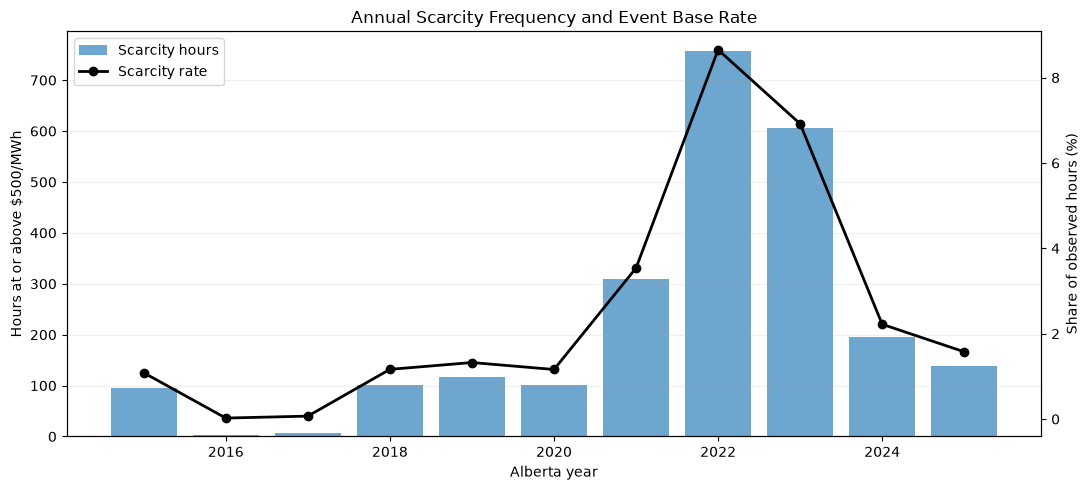

In [9]:
# ---------------------------------------------------------------------
# Plot Annual Scarcity Count and Base Rate
# ---------------------------------------------------------------------

fig, ax_count = plt.subplots(figsize=(11, 5))

ax_count.bar(
    annual_events.index, annual_events["hours_at_or_above_500"],
    alpha=0.65, label="Scarcity hours",
)
ax_count.set(xlabel="Alberta year", ylabel="Hours at or above $500/MWh",
             title="Annual Scarcity Frequency and Event Base Rate")
ax_count.grid(axis="y", alpha=0.20)

ax_rate = ax_count.twinx()
ax_rate.plot(
    annual_events.index, annual_events["scarcity_base_rate_pct"],
    color="black", marker="o", linewidth=2, label="Scarcity rate",
)
ax_rate.set_ylabel("Share of observed hours (%)")

lines_1, labels_1 = ax_count.get_legend_handles_labels()
lines_2, labels_2 = ax_rate.get_legend_handles_labels()
ax_count.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

#### Annual Event Base Rates

The clearest break occurs after 2020. Average pool price rose from \$46.72/MWh in 2020 to \$101.93/MWh in 2021 and peaked at \$162.46/MWh in 2022. Scarcity followed the same pattern, reaching 758 hours above \$500/MWh in 2022 and 606 in 2023.

By 2024–2025, the market had cooled considerably. Prices and scarcity hours both fell, but high-price events were still more common than in the unusually quiet 2016–2017 period.

## 3. Demand Pressure and Net Load

### 3.1 Load and Net-Load Distributions

Gross load measures total Alberta Internal Load. Net load subtracts wind and solar generation and approximates the demand that must be met by dispatchable generation, hydro, imports and other system resources. 

In [10]:
# ---------------------------------------------------------------------
# Compare Load and Net Load During Scarcity
# ---------------------------------------------------------------------

primary_event = scarcity_features[f"price_at_or_above_{PRIMARY_SCARCITY_THRESHOLD}"]

demand_comparison = compare_event_means({
    "Alberta Internal Load (MW)": master["ail_mw"],
    "Net load (MW)": scarcity_features["net_load_mw"],
    "Variable renewable generation (MW)": scarcity_features["variable_renewable_generation_mw"],
}, primary_event)

display(demand_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Alberta Internal Load (MW),9655.33,10458.94,9654.00,10506.50,803.62,8.32
Net load (MW),8724.61,9989.69,8741.16,9985.83,1265.08,14.50
Variable renewable generation (MW),930.71,469.25,726.89,355.80,-461.46,-49.58


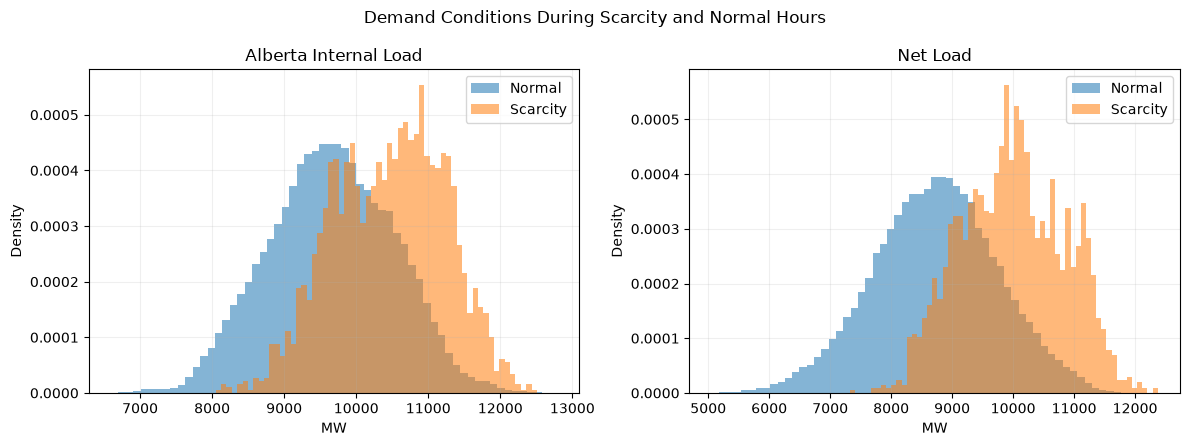

In [11]:
# ---------------------------------------------------------------------
# Plot Load and Net-Load Distributions
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

distribution_features = {
    "Alberta Internal Load": master["ail_mw"],
    "Net Load": scarcity_features["net_load_mw"],
}

for ax, (label, values) in zip(axes, distribution_features.items()):
    ax.hist(values.loc[~primary_event].dropna(), bins=60, density=True, alpha=0.55, label="Normal")
    ax.hist(values.loc[primary_event].dropna(), bins=60, density=True, alpha=0.55, label="Scarcity")
    ax.set(title=label, xlabel="MW", ylabel="Density")
    ax.grid(alpha=0.20)
    ax.legend()

fig.suptitle("Demand Conditions During Scarcity and Normal Hours")
plt.tight_layout()
plt.show()

#### Load and Net-Load Distributions

Scarcity hours tend to occur when demand is high and renewable generation is low. Alberta Internal Load averages about 804 MW higher during scarcity (+8.3%), while net load is 1,265 MW higher (+14.5%).

The larger increase in net load comes from weaker renewable output alongside higher demand. Wind and solar generation average 469 MW during scarcity, roughly half the normal-hour average. Together, these results show that scarcity is associated with elevated demand, weaker renewable generation, and greater requirement for dispatchable supply.

### 3.2 Net-Load Deciles

Net load is ranked within each year so that the comparison is not driven by long-run demand growth or renewable expansion.

Scarcity lift compares the scarcity rate in each decile with that year’s overall scarcity rate:

$$
\text{Scarcity Lift}
=
\frac{\text{Scarcity Rate in Year-Decile}}{\text{Annual Scarcity Rate}}
$$

A consistent relationship should show scarcity concentrated in the upper net-load deciles across years.

In [12]:
# ---------------------------------------------------------------------
# Build and Plot Year-by-Decile Scarcity Summaries
# ---------------------------------------------------------------------

def build_year_decile_summary(values, event):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "value": values,
        "event": event,
    }).dropna()

    frame["decile"] = frame.groupby("year_alberta")["value"].transform(
        lambda s: percentile_to_decile(s.rank(method="average", pct=True))
    )

    annual_base_rate = frame.groupby("year_alberta")["event"].mean().rename("annual_base_rate")

    summary = (
        frame.groupby(["year_alberta", "decile"], observed=True)
        .agg(hours=("event", "size"), scarcity_rate=("event", "mean"), average_value=("value", "mean"))
        .reset_index()
        .merge(annual_base_rate, on="year_alberta", how="left")
    )

    summary["scarcity_lift"] = summary["scarcity_rate"] / summary["annual_base_rate"].replace(0, np.nan)
    return summary

# ---------------------------------------------------------------------
# Plot Year-by-Decile Scarcity Lift
# ---------------------------------------------------------------------

def plot_year_decile_heatmap(summary, title, minimum_hours=100):
    lift = summary.pivot(index="year_alberta", columns="decile", values="scarcity_lift")
    counts = summary.pivot(index="year_alberta", columns="decile", values="hours")
    displayed_lift = lift.where(counts.ge(minimum_hours))

    fig, ax = plt.subplots(figsize=(11, 6))
    image = ax.imshow(displayed_lift, aspect="auto", cmap="RdYlBu_r", vmin=0)

    ax.set_xticks(range(len(displayed_lift.columns)), labels=displayed_lift.columns)
    ax.set_yticks(range(len(displayed_lift.index)), labels=displayed_lift.index)
    ax.set(
        xlabel="Within-year decile (0 = lowest, 9 = highest)",
        ylabel="Alberta year",
        title=title,
    )

    fig.colorbar(image, ax=ax, label="Scarcity lift over annual base rate")
    plt.tight_layout()
    plt.show()

    return counts

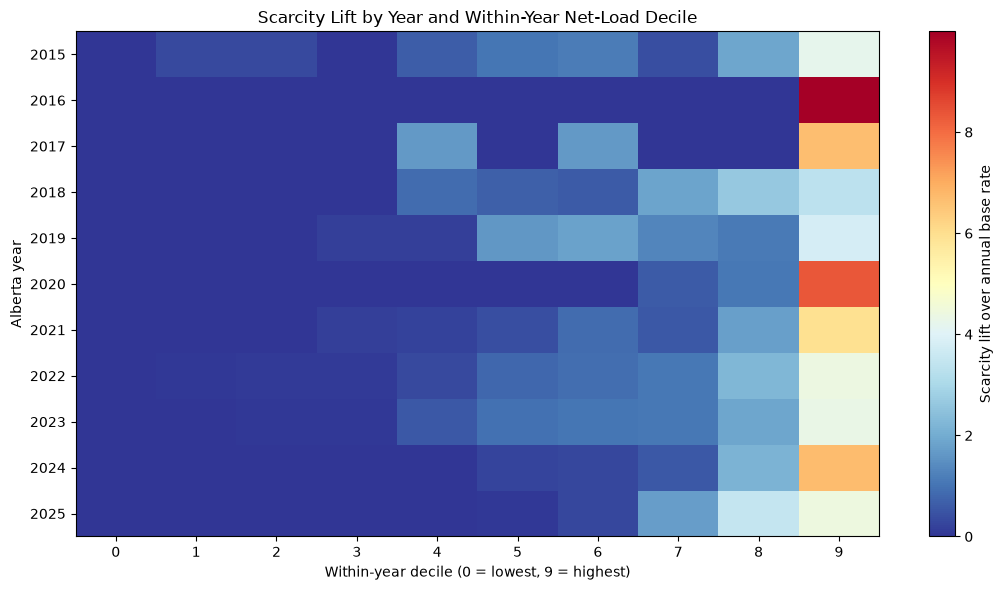

In [13]:
# ---------------------------------------------------------------------
# Net-Load Year-by-Decile Stability
# ---------------------------------------------------------------------

net_load_year_deciles = build_year_decile_summary(
    scarcity_features["net_load_mw"], primary_event
)

net_load_decile_counts = plot_year_decile_heatmap(
    net_load_year_deciles,
    title="Scarcity Lift by Year and Within-Year Net-Load Decile",
)

net_load_decile_values = (
    net_load_year_deciles
    .pivot(index="year_alberta", columns="decile", values="scarcity_lift")
    .sort_index()
)

#### Net-Load Deciles

Scarcity risk is consistently concentrated in the highest within-year net-load deciles. The lowest decile records no scarcity events in any year, while the tenth decile produces the largest scarcity lift throughout the sample. This relationship is especially pronounced in 2024 and 2025, when lift begins rising sharply in the upper three deciles.

The pattern is broadly stable but not perfectly monotonic, particularly in years containing few scarcity events. Large tenth-decile lifts in 2016, 2017, and 2020 should therefore be interpreted cautiously: they show that the limited events were highly concentrated at extreme net load, not necessarily that those years had high absolute scarcity risk. Overall, extreme net load appears to be a persistent indicator of scarcity across different market regimes.

### 3.3 Net-load across structural regimes

The net-load relationship is also compared across the four structural market regimes, and changes in generation compositions. 

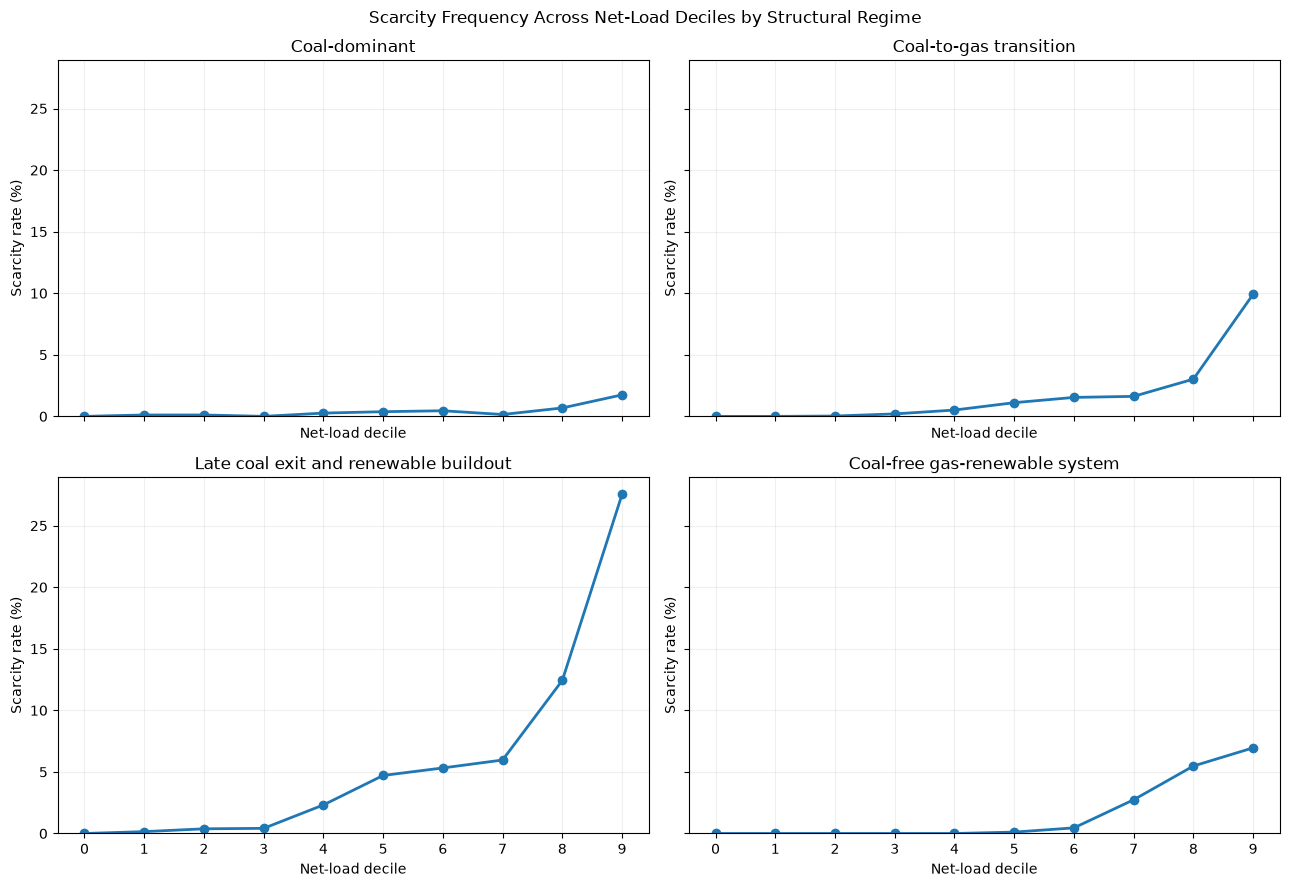

In [14]:
# ---------------------------------------------------------------------
# Compare Net-Load Deciles Across Structural Regimes
# ---------------------------------------------------------------------

net_load_regime_summary = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "net_load_decile": scarcity_features["net_load_decile"],
        "scarcity_event": primary_event,
    })
    .dropna()
    .groupby(["structural_regime", "net_load_decile"], observed=True)
    .agg(hours=("scarcity_event", "size"), scarcity_rate=("scarcity_event", "mean"))
    .reset_index()
)

# ---------------------------------------------------------------------
# Plot Scarcity Frequency by Regime and Net-Load Decile
# ---------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
maximum_rate = net_load_regime_summary["scarcity_rate"].max() * 100

for ax, regime in zip(axes.flatten(), STRUCTURAL_REGIME_ORDER):
    plot_data = net_load_regime_summary.loc[
        net_load_regime_summary["structural_regime"].eq(regime)
    ]

    ax.plot(
        plot_data["net_load_decile"],
        plot_data["scarcity_rate"] * 100,
        marker="o",
        linewidth=2,
    )
    ax.set(
        title=regime,
        xlabel="Net-load decile",
        ylabel="Scarcity rate (%)",
        ylim=(0, maximum_rate * 1.05),
    )
    ax.set_xticks(range(10))
    ax.grid(alpha=0.20)

fig.suptitle("Scarcity Frequency Across Net-Load Deciles by Structural Regime")
plt.tight_layout()
plt.show()

#### Net-load across structural regimes

Scarcity is concentrated in the upper end of the net-load distribution across all four regimes. The relationship is not generally smooth or linear: scarcity remains relatively uncommon through most deciles before rising sharply in the highest two or three.

The 2022–2024 regime is the main exception, with scarcity increasing more steadily across the net-load distribution. This period also had an unusually high scarcity base rate and elevated fuel prices, so its stronger gradient should be interpreted in that broader market context.

Overall, net load appears most useful as a marker of the system entering its tightest operating states rather than as a simple linear driver of scarcity.

### 3.4 Net-Load Changes at Scarcity Onset

Net-load changes over one, six, and 24 hours are examined at the onset of each scarcity episode.

This is a descriptive event-onset analysis, not an exhaustive lag-selection exercise. Formal temporal-feature selection belongs in Notebook 5 and the forecasting notebooks.

In [15]:
# ---------------------------------------------------------------------
# Compare Net-Load Changes Across Scarcity States
# ---------------------------------------------------------------------

event_onset = primary_event & ~primary_event.shift(fill_value=False)
continuing_scarcity = primary_event & ~event_onset

scarcity_state = pd.Series(
    np.select(
        [event_onset, continuing_scarcity],
        ["Event onset", "Continuing scarcity"],
        default="Non-scarcity",
    ),
    index=master.index,
    name="scarcity_state",
)

# ---------------------------------------------------------------------
# Summarize Net-Load Ramps by Horizon and Scarcity State
# ---------------------------------------------------------------------

net_load_ramp_rows = []

for horizon in [1, 6, 24]:
    ramp_frame = pd.DataFrame({
        "scarcity_state": scarcity_state,
        "net_load_change_mw": scarcity_features["net_load_mw"] - scarcity_features["net_load_mw"].shift(horizon),
    }).dropna()

    horizon_summary = (
        ramp_frame.groupby("scarcity_state", observed=True)
        .agg(
            observations=("net_load_change_mw", "size"),
            mean_change_mw=("net_load_change_mw", "mean"),
            median_change_mw=("net_load_change_mw", "median"),
            change_25th_percentile_mw=("net_load_change_mw", lambda s: s.quantile(0.25)),
            change_75th_percentile_mw=("net_load_change_mw", lambda s: s.quantile(0.75)),
        )
        .reset_index()
    )

    horizon_summary["horizon_hours"] = horizon
    net_load_ramp_rows.append(horizon_summary)

# ---------------------------------------------------------------------
# Assemble Final Net-Load Ramp Summary
# ---------------------------------------------------------------------

state_order = ["Non-scarcity", "Event onset", "Continuing scarcity"]

net_load_onset_ramps = pd.concat(net_load_ramp_rows, ignore_index=True)[[
    "horizon_hours", "scarcity_state", "observations", "mean_change_mw",
    "median_change_mw", "change_25th_percentile_mw", "change_75th_percentile_mw",
]]

net_load_onset_ramps["scarcity_state"] = pd.Categorical(
    net_load_onset_ramps["scarcity_state"], categories=state_order, ordered=True
)

net_load_onset_ramps = (
    net_load_onset_ramps
    .sort_values(["horizon_hours", "scarcity_state"])
    .reset_index(drop=True)
)

display(net_load_onset_ramps.round(2))

,horizon_hours,scarcity_state,observations,mean_change_mw,median_change_mw,change_25th_percentile_mw,change_75th_percentile_mw
0,1,Non-scarcity,94001,-1.29,-6.85,-128.24,113.90
1,1,Event onset,758,117.21,105.06,4.34,217.17
2,1,Continuing scarcity,1672,20.20,18.00,-81.54,109.99
3,6,Non-scarcity,93996,-14.03,-6.58,-613.44,573.16
4,6,Event onset,758,629.88,585.11,239.18,991.09
5,6,Continuing scarcity,1672,506.78,485.13,194.44,820.53
6,24,Non-scarcity,93978,-9.80,-5.37,-412.00,389.32
7,24,Event onset,758,426.98,285.78,16.25,752.22
8,24,Continuing scarcity,1672,363.26,263.49,-2.84,633.34


#### Net-Load Changes at Scarcity Onset

Scarcity onset is associated with substantial increases in net load. During the first hour of a scarcity episode, net load increased by an average of approximately 117 MW over the preceding hour, 630 MW over six hours, and 427 MW over 24 hours. Median changes were similarly positive—105 MW, 585 MW, and 286 MW, respectively—indicating that the pattern is not driven solely by a small number of extreme events.

The largest separation occurs over the six-hour horizon. The middle 50% of onset observations experienced six-hour net-load increases ranging from approximately 239 MW to 991 MW. By comparison, non-scarcity hours had an average six-hour change of −14 MW and a median change of −7 MW.

Net load also remained elevated during continuing scarcity hours. Average changes during ongoing events were approximately 20 MW over one hour, 507 MW over six hours, and 363 MW over 24 hours. This suggests that scarcity episodes frequently begin during sustained multi-hour increases in net load rather than isolated one-hour movements.

Overall, the results show that scarcity onset is commonly preceded by a pronounced buildup in net load, particularly over the preceding six hours. However, these changes include net load observed in the scarcity hour itself. They should therefore be interpreted as descriptive event-onset patterns rather than as confirmed advance forecasting signals.

## 4. Supply Availability, Outages, and Interties

### 4.1 Thermal Availability and Headroom

**Thermal availability** is the reported coal- and gas-fired capacity available in each hour.

**Thermal headroom** is the portion of that available capacity not currently generating:

$$
\text{Thermal Headroom}
=
\text{Thermal Availability}
-
\text{Thermal Generation}
$$

This avoids comparing thermal availability directly with total load, which is also served by hydro, renewables, imports, and other resources.

In [16]:
# ---------------------------------------------------------------------
# Compare Thermal Conditions
# ---------------------------------------------------------------------

thermal_comparison = compare_event_means({
    "Reported thermal availability (MW)": scarcity_features["reported_thermal_available_mw"],
    "Reported thermal generation (MW)": scarcity_features["reported_thermal_generation_mw"],
    "Thermal headroom (MW)": scarcity_features["thermal_headroom_mw"],
    "Thermal utilization (%)": scarcity_features["thermal_utilization_pct"],
}, primary_event)

display(thermal_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Reported thermal availability (MW),9752.18,9253.68,9728.00,9281.00,-498.50,-5.11
Reported thermal generation (MW),5896.35,6548.21,5891.51,6514.43,651.85,11.06
Thermal headroom (MW),3855.83,2705.48,3777.48,2675.35,-1150.35,-29.83
Thermal utilization (%),60.49,70.74,60.97,70.76,10.25,16.95


In [17]:
# ---------------------------------------------------------------------
# Audit Technology-Level Thermal Availability
# ---------------------------------------------------------------------

technology_availability_rows = []

for technology in THERMAL_TECHNOLOGIES:
    column = f"{technology}_system_available"
    reported = master[column].notna()

    technology_availability_rows.append({
        "technology": technology,
        "coverage_pct": reported.mean() * 100,
        "first_reported": master.loc[reported, "timestamp_alberta"].min(),
        "last_reported": master.loc[reported, "timestamp_alberta"].max(),
        "normal_mean_mw": master.loc[reported & ~primary_event, column].mean(),
        "scarcity_mean_mw": master.loc[reported & primary_event, column].mean(),
    })

technology_availability = pd.DataFrame(technology_availability_rows)
technology_availability["difference_mw"] = technology_availability["scarcity_mean_mw"] - technology_availability["normal_mean_mw"]
technology_availability["pct_difference"] = technology_availability["difference_mw"] / technology_availability["normal_mean_mw"].replace(0, np.nan) * 100

technology_availability_display = technology_availability.copy()
numeric_columns = technology_availability_display.select_dtypes(include="number").columns
technology_availability_display[numeric_columns] = technology_availability_display[numeric_columns].round(2)

display(technology_availability_display)

,technology,coverage_pct,first_reported,last_reported,normal_mean_mw,scarcity_mean_mw,difference_mw,pct_difference
0,coal,86.34,2015-01-01 00:00:00-07:00,2024-06-30 23:00:00-06:00,3507.37,1723.32,-1784.05,-50.87
1,cogeneration,100.00,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,3093.93,3197.85,103.93,3.36
2,combined_cycle,100.00,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,1686.93,1678.51,-8.43,-0.50
3,dual_fuel,51.77,2018-03-05 00:00:00-07:00,2024-07-11 23:00:00-06:00,447.83,453.02,5.20,1.16
4,gas_fired_steam,44.67,2021-02-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,2204.72,2168.90,-35.82,-1.62
5,simple_cycle,100.00,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,753.52,729.55,-23.96,-3.18


In [18]:
# ---------------------------------------------------------------------
# Audit Internal Dual-Fuel Reporting Gap
# ---------------------------------------------------------------------

dual_fuel_gap = scarcity_features["dual_fuel_reporting_gap"]

dual_fuel_gap_audit = pd.DataFrame([{
    "affected_hours": int(dual_fuel_gap.sum()),
    "first_affected_hour": master.loc[dual_fuel_gap, "timestamp_alberta"].min(),
    "last_affected_hour": master.loc[dual_fuel_gap, "timestamp_alberta"].max(),
    "availability_missing_hours": int((dual_fuel_gap & master["dual_fuel_system_available"].isna()).sum()),
    "generation_missing_hours": int((dual_fuel_gap & master["dual_fuel_system_generation"].isna()).sum()),
    "scarcity_hours_during_gap": int((dual_fuel_gap & primary_event).sum()),
}])

display(dual_fuel_gap_audit)

,affected_hours,first_affected_hour,last_affected_hour,availability_missing_hours,generation_missing_hours,scarcity_hours_during_gap
0,5783,2022-03-08 00:00:00-07:00,2022-11-03 23:00:00-06:00,5783,5783,457


#### Thermal Availability and Headroom

Scarcity hours are characterized by a substantially tighter thermal supply position. Reported thermal availability averages approximately 498 MW lower, while thermal generation is about 652 MW higher. Together, these changes reduce average thermal headroom by roughly 1,150 MW, or 29.8%. Thermal utilization consequently rises from 60.5% during normal hours to 70.7% during scarcity—an increase of 10.25 percentage points.

The technology-level availability results require more cautious interpretation because reporting coverage and fleet composition change over time. In particular, coal availability is much lower during scarcity largely because scarcity became more frequent as Alberta’s coal fleet declined. Availability for cogeneration, combined-cycle, dual-fuel, gas-fired steam, and simple-cycle resources differs relatively little between normal and scarcity hours.

Overall, scarcity appears to reflect greater use of a smaller reported thermal availability stack rather than widespread reductions in the availability of every thermal technology. Regime-controlled comparisons are necessary to separate immediate operational tightness from Alberta’s longer-term generation transition.

> Dual-fuel availability and generation are missing for 5,783 hours between March 8 and November 3, 2022, including 457 scarcity hours. During this period, thermal totals are calculated from the remaining reported technologies; missing dual-fuel values are not imputed. These hours are flagged separately and will be excluded in a sensitivity check of the thermal-headroom results.

### 4.2 Absolute and Relative Outage Burden

Absolute outages measure unavailable generation in MW. Relative outage burden divides total outages by reported system capacity. 

The relative measure helps distinguish a large outage in a smaller historical fleet from the same outage magnitude after the fleet expanded. 

In [19]:
# ---------------------------------------------------------------------
# Compare Outage Conditions
# ---------------------------------------------------------------------

outage_comparison = compare_event_means({
    "Total outages (MW)": master["total_outage_mw"],
    "Thermal outages (MW)": master["thermal_outage_mw"],
    "Renewable outages (MW)": master["renewable_outage_mw"],
    "Simple-cycle outages (MW)": master["simple_cycle_outage"],
    "Combined-cycle outages (MW)": master["combined_cycle_outage"],
    "Cogeneration outages (MW)": master["cogeneration_outage"],
    "Outage share of capacity (%)": scarcity_features["outage_share_of_capacity_pct"],
}, primary_event)

display(outage_comparison.sort_values("mean_pct_difference", ascending=False).round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Renewable outages (MW),465.84,749.97,319.30,628.30,284.13,60.99
Simple-cycle outages (MW),253.74,373.53,211.40,347.40,119.79,47.21
Total outages (MW),3542.23,3883.47,3473.30,3810.40,341.24,9.63
Cogeneration outages (MW),1411.71,1533.68,1378.00,1600.35,121.97,8.64
Outage share of capacity (%),20.79,22.17,20.69,22.06,1.37,6.61
Thermal outages (MW),3072.28,3125.08,3049.10,3095.10,52.80,1.72
Combined-cycle outages (MW),467.50,435.66,284.00,259.00,-31.84,-6.81


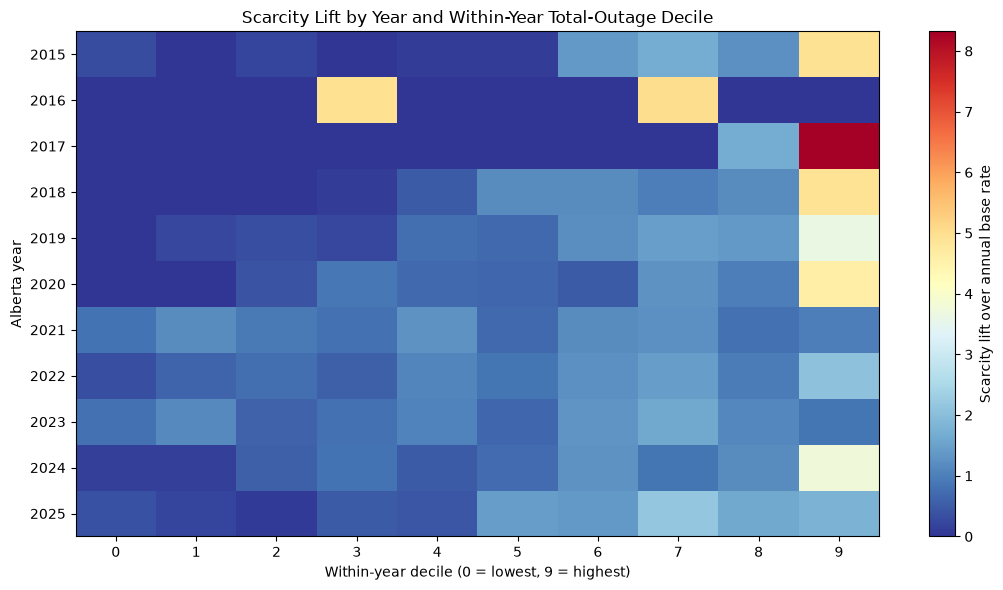

In [20]:
# ---------------------------------------------------------------------
# Test Annual Stability of Total-Outage Burden
# ---------------------------------------------------------------------

outage_year_deciles = build_year_decile_summary(master["total_outage_mw"], primary_event)

outage_decile_counts = plot_year_decile_heatmap(
    outage_year_deciles,
    title="Scarcity Lift by Year and Within-Year Total-Outage Decile",
)

outage_year_decile_values = (
    outage_year_deciles
    .pivot(index="year_alberta", columns="decile", values="scarcity_lift")
    .sort_index()
)

#### Absolute and Relative Outage Burden

Scarcity hours have higher outage levels, but the relationship varies by technology. Renewable and simple-cycle outages show the largest differences, increasing by 61% and 47%, while total outages are only 9.6% higher and aggregate thermal outages just 1.7% higher.

The relationship is also inconsistent across years. Extreme outage conditions align strongly with scarcity in several years, but much less so during 2021–2023. Outages therefore appear to contribute to system tightness without providing a stable standalone explanation for scarcity.

### 4.3 Imports and Intertie Capability

Observed imports show how much external power actually entered Alberta, while import capability measures how much transfer capacity was available across the interties.

The distinction matters because imports can increase in response to scarcity, while limited intertie capability can restrict how much support is available. Observed imports may also not be known at the time a forecast is made.

In [21]:
# ---------------------------------------------------------------------
# Audit Intertie Flow and Capability Coverage
# ---------------------------------------------------------------------

INTERTIE_COLUMNS = [
    "total_imports_mw", "total_exports_mw", "net_imports_mw",
    "atc_sk_import", "atc_wecc_import", "ttc_sk_import", "ttc_wecc_import",
]

intertie_reporting = pd.DataFrame({
    "missing_hours": master[INTERTIE_COLUMNS].isna().sum(),
    "coverage_pct": master[INTERTIE_COLUMNS].notna().mean() * 100,
    "mean": master[INTERTIE_COLUMNS].mean(),
    "minimum": master[INTERTIE_COLUMNS].min(),
    "maximum": master[INTERTIE_COLUMNS].max(),
})

display(intertie_reporting.round(2))

,missing_hours,coverage_pct,mean,minimum,maximum
total_imports_mw,3673,96.19,262.94,0.0,1154.0
total_exports_mw,3673,96.19,131.52,0.0,1232.0
net_imports_mw,3673,96.19,131.42,-1082.0,1154.0
atc_sk_import,0,100.00,119.36,0.0,153.0
atc_wecc_import,0,100.00,587.50,0.0,1110.0
ttc_sk_import,0,100.00,123.67,0.0,153.0
ttc_wecc_import,0,100.00,1048.80,0.0,1110.0


In [22]:
# ---------------------------------------------------------------------
# Compare Intertie Conditions
# ---------------------------------------------------------------------

intertie_comparison = compare_event_means({
    "Total imports (MW)": master["total_imports_mw"],
    "Total exports (MW)": master["total_exports_mw"],
    "Net imports (MW)": master["net_imports_mw"],
    "Net imports as share of load (%)": scarcity_features["net_import_share_of_load_pct"],
    "Reported import ATC (MW)": scarcity_features["import_atc_mw"],
    "Reported import TTC (MW)": scarcity_features["import_ttc_mw"],
}, primary_event)

display(intertie_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Total imports (MW),256.39,515.71,153.0,527.00,259.32,101.14
Total exports (MW),133.74,45.69,0.0,0.00,-88.06,-65.84
Net imports (MW),122.64,470.02,100.0,511.00,347.38,283.24
Net imports as share of load (%),1.30,4.49,1.0,5.03,3.20,246.57
Reported import ATC (MW),709.17,617.28,721.0,657.50,-91.89,-12.96
Reported import TTC (MW),1173.01,1151.48,1263.0,1200.00,-21.53,-1.84


#### Imports and Intertie Capability

Observed intertie flows are available for 96.2% of the study period, while reported Saskatchewan and WECC transfer capabilities have complete coverage. Missing flow observations are retained as missing and are not interpreted as zero imports or exports.

Alberta relies much more heavily on imported electricity during scarcity. Total imports average approximately 516 MW—more than twice their normal-hour level—while exports fall by about 88 MW. Net imports consequently rise from 123 MW during normal hours to 470 MW during scarcity, increasing from 1.3% to 4.5% of Alberta load.

At the same time, reported import ATC averages approximately 92 MW lower during scarcity, a decline of 13%, whereas TTC is only 2% lower. This suggests that scarcity is associated with greater import dependence despite less immediately available transfer capability. The results do not establish whether imports mitigate scarcity, respond to high Alberta prices, or reflect a common tight-system condition; that distinction requires temporal and joint-condition analysis.

## 5. Available System Margin

### 5.1 Capacity, availability, and system headroom

This section compares four measures of system tightness:

- **Reported capacity margin:** installed capacity minus load.
- **Domestic available margin:** reported available supply minus load.
- **Intertie-supported margin:** domestic available margin plus observed net imports.
- **Reported supply headroom:** reported available supply minus actual generation.

These measures capture different aspects of system tightness and should not be interpreted as official AESO operating-reserve measures.

In [23]:
# ---------------------------------------------------------------------
# Compare Capacity and Availability-Based Margins
# ---------------------------------------------------------------------

margin_comparison = compare_event_means({
    "Reported capacity margin (MW)": scarcity_features["reported_capacity_margin_mw"],
    "Domestic available margin (MW)": scarcity_features["domestic_available_margin_mw"],
    "Intertie-supported margin (MW)": scarcity_features["intertie_supported_margin_mw"],
    "Reported supply headroom (MW)": scarcity_features["reported_supply_headroom_mw"],
    "Available margin as share of load (%)": scarcity_features["available_margin_pct_of_load"],
}, primary_event)

display(margin_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Reported capacity margin (MW),7454.41,7086.33,6671.40,6749.08,-368.07,-4.94
Domestic available margin (MW),3764.15,3083.78,3169.00,2913.00,-680.37,-18.07
Intertie-supported margin (MW),3729.63,3410.65,3295.00,3317.00,-318.98,-8.55
Reported supply headroom (MW),6317.73,6122.93,5744.10,6044.46,-194.81,-3.08
Available margin as share of load (%),39.26,29.77,34.11,27.94,-9.49,-24.16


#### Capacity, availability, and system headroom

Scarcity hours are associated with tighter operational margins, although the magnitude depends on how available supply is measured. Reported capacity margin is approximately 368 MW lower during scarcity, a decline of only 4.9%. In contrast, domestic available margin falls by roughly 680 MW, or 18.1%, and declines from 39.3% to 29.8% of Alberta load.

Accounting for net imports reduces the difference: intertie-supported margin is approximately 319 MW lower during scarcity, compared with the 680 MW reduction in domestic available margin. This indicates that increased imports partially offset tighter domestic supply conditions, although they do not eliminate the margin reduction.

Reported supply headroom changes comparatively little, declining by about 3% on average, while its median is slightly higher during scarcity. Overall, operational availability relative to load appears more closely associated with scarcity than reported fleet capacity alone, reinforcing the distinction between the size of the generation fleet and the supply actually available during stressed hours.

### 5.2 Available-Margin Deciles and Annual Stability

Domestic available margin is ranked within each year. Decile 0 contains the tightest 10% of available-margin hours, while decile 9 contains the loosest 10%.

Using within-year deciles prevents structural capacity growth from obscuring the operating relationship.

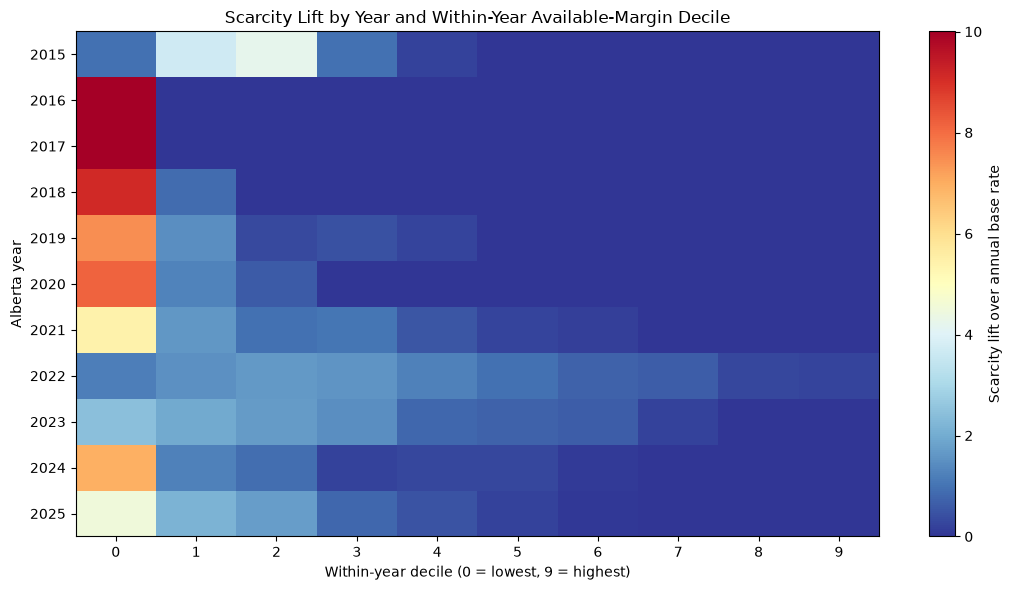

In [24]:
# ---------------------------------------------------------------------
# Available-Margin Year-by-Decile Stability
# ---------------------------------------------------------------------

available_margin_year_deciles = build_year_decile_summary(
    scarcity_features["domestic_available_margin_mw"], primary_event
)

available_margin_decile_counts = plot_year_decile_heatmap(
    available_margin_year_deciles,
    title="Scarcity Lift by Year and Within-Year Available-Margin Decile",
)

available_margin_year_decile_values = (
    available_margin_year_deciles
    .pivot(index="year_alberta", columns="decile", values="scarcity_lift")
    .sort_index()
)

#### Available-Margin Deciles and Annual Stability

Scarcity is generally concentrated in hours with the lowest domestic available margins. In most years, scarcity lift is highest in the bottom margin deciles and falls toward zero as available margin increases. During 2016–2018, 2020, and 2024, the lowest decile captures an especially large share of the year’s scarcity events.

The relationship is less concentrated during 2021–2023. In 2022, scarcity remained elevated across several middle-margin deciles, suggesting that the unusually high base rate that year cannot be explained by only the most margin-constrained hours. Fuel costs, renewable conditions, outages, imports, or other regime-specific factors may also have contributed.

Overall, low domestic available margin is a persistent scarcity indicator, but its strength varies across years. Rare-event years produce particularly large lowest-decile lifts, while high-scarcity years display a broader distribution of risk across operating conditions.

### 5.3 Available-Margin States

Four operating states are defined from each year’s domestic available-margin distribution:

- **Critical:** bottom 5%;
- **Tight:** 5th–20th percentile;
- **Balanced:** 20th–80th percentile; and
- **Loose:** top 20%.

These states describe relative operating tightness within each year rather than imposing a single MW threshold on a generation fleet that changed substantially over time.

In [25]:
# ---------------------------------------------------------------------
# Profile Available-Margin States
# ---------------------------------------------------------------------

margin_state_profile = (
    pd.DataFrame({
        "margin_state": scarcity_features["margin_state"],
        "event_300": scarcity_features["price_at_or_above_300"],
        "event_500": scarcity_features["price_at_or_above_500"],
        "event_900": scarcity_features["price_at_or_above_900"],
        "pool_price": master["pool_price"],
        "ail_mw": master["ail_mw"],
        "net_load_mw": scarcity_features["net_load_mw"],
        "available_margin_mw": scarcity_features["domestic_available_margin_mw"],
        "thermal_headroom_mw": scarcity_features["thermal_headroom_mw"],
        "total_outage_mw": master["total_outage_mw"],
        "net_imports_mw": master["net_imports_mw"],
    })
    .groupby("margin_state", observed=True)
    .agg(
        hours=("event_500", "size"),
        high_price_rate=("event_300", "mean"),
        scarcity_rate=("event_500", "mean"),
        extreme_rate=("event_900", "mean"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
        price_75th_percentile=("pool_price", lambda s: s.quantile(0.75)),
        price_90th_percentile=("pool_price", lambda s: s.quantile(0.90)),
        average_load_mw=("ail_mw", "mean"),
        average_net_load_mw=("net_load_mw", "mean"),
        average_available_margin_mw=("available_margin_mw", "mean"),
        average_thermal_headroom_mw=("thermal_headroom_mw", "mean"),
        average_total_outage_mw=("total_outage_mw", "mean"),
        average_net_imports_mw=("net_imports_mw", "mean"),
    )
    .reindex(MARGIN_STATE_ORDER)
)

for column in ["high_price_rate", "scarcity_rate", "extreme_rate"]:
    margin_state_profile[f"{column}_pct"] = margin_state_profile[column] * 100

display(margin_state_profile.round(2))

,hours,high_price_rate,scarcity_rate,extreme_rate,average_price,median_price,price_75th_percentile,price_90th_percentile,average_load_mw,average_net_load_mw,average_available_margin_mw,average_thermal_headroom_mw,average_total_outage_mw,average_net_imports_mw,high_price_rate_pct,scarcity_rate_pct,extreme_rate_pct
margin_state,,,,,,,,,,,,,,,,,
Critical,4820,0.17,0.13,0.04,167.63,52.39,130.97,631.40,10523.61,9516.51,2106.00,2905.75,4112.35,397.51,17.10,12.61,4.15
Tight,14461,0.08,0.05,0.01,96.32,39.66,73.91,215.23,10261.42,9280.62,2740.05,3278.33,3779.31,271.58,7.76,4.73,0.86
Balanced,57858,0.03,0.02,0.00,60.83,32.99,51.59,96.47,9713.57,8800.94,3742.70,3786.67,3530.98,122.33,3.40,1.89,0.17
Loose,19293,0.01,0.00,0.00,35.23,26.75,35.90,61.39,8910.66,8040.46,4924.62,4588.57,3298.78,-5.55,0.69,0.22,0.00


#### Available-Margin States

Price outcomes deteriorate sharply as domestic available margin tightens. Critical-margin hours have an average pool price of $167.71/MWh and a scarcity rate of 12.62%, compared with $35.23/MWh and 0.22% during loose-margin conditions. Extreme prices occur during 4.15% of critical hours but are effectively absent when margins are loose.

Critical conditions combine higher load and net load with lower thermal headroom, greater outages, and increased reliance on imports. Average net imports rise to approximately 398 MW during critical hours, compared with slight net exports during loose conditions. The consistent progression across margin states indicates that the within-year available-margin classification captures economically meaningful changes in system tightness.

### 5.4 Margin-State Stability Across Structural Regimes

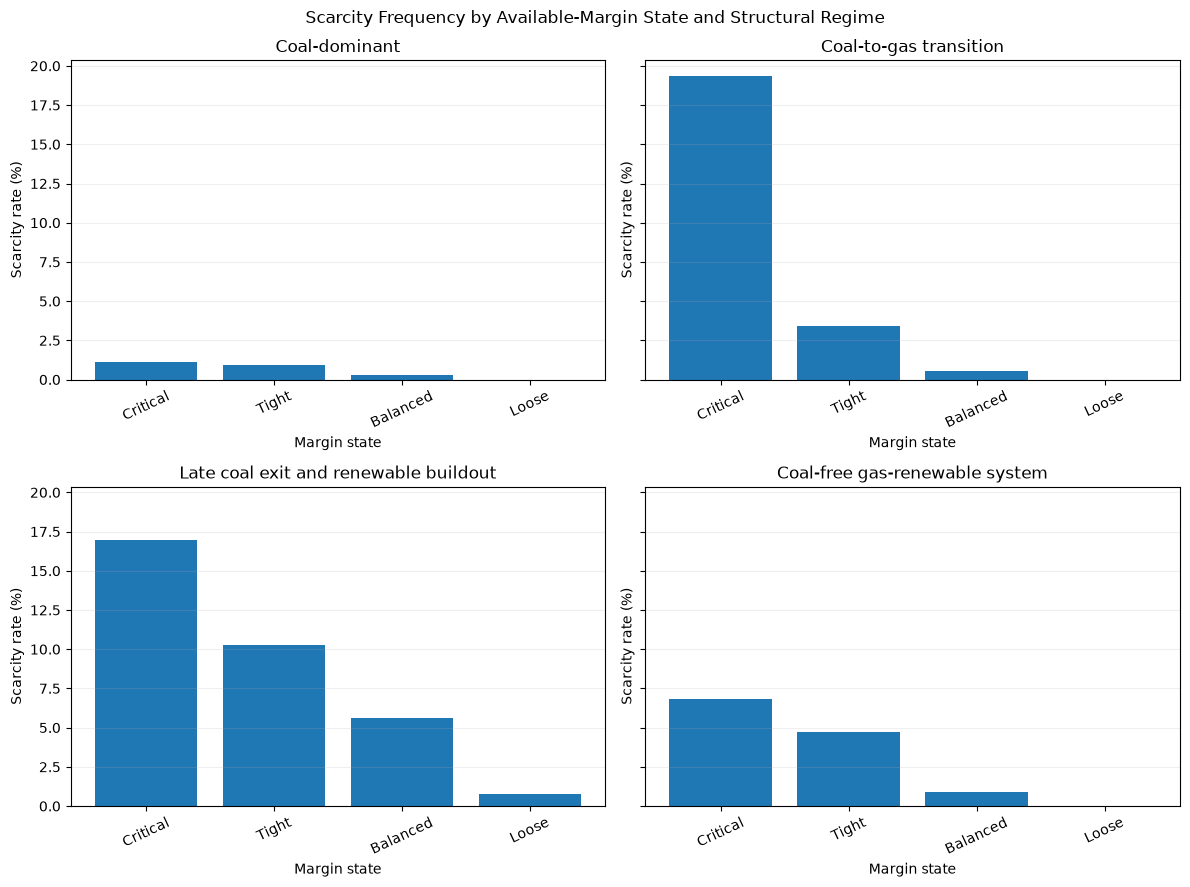

In [26]:
# ---------------------------------------------------------------------
# Compare Margin States Across Structural Regimes
# ---------------------------------------------------------------------

regime_margin_summary = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "margin_state": scarcity_features["margin_state"],
        "scarcity_event": primary_event,
    })
    .groupby(["structural_regime", "margin_state"], observed=True)
    .agg(hours=("scarcity_event", "size"), scarcity_rate=("scarcity_event", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
maximum_rate = regime_margin_summary["scarcity_rate"].max() * 100

for axis, regime in zip(axes.flatten(), STRUCTURAL_REGIME_ORDER):
    plot_data = (
        regime_margin_summary.loc[regime_margin_summary["structural_regime"].eq(regime)]
        .set_index("margin_state")
        .reindex(MARGIN_STATE_ORDER)
    )

    axis.bar(plot_data.index, plot_data["scarcity_rate"] * 100)
    axis.set(
        title=regime,
        xlabel="Margin state",
        ylabel="Scarcity rate (%)",
        ylim=(0, maximum_rate * 1.05),
    )
    axis.tick_params(axis="x", labelbottom=True, rotation=25)
    axis.grid(axis="y", alpha=0.20)

fig.suptitle("Scarcity Frequency by Available-Margin State and Structural Regime")
plt.tight_layout()
plt.show()

#### Margin-State Stability Across Structural Regimes

The inverse relationship between available margin and scarcity persists across all four structural regimes: scarcity rates are highest during critical-margin hours and generally decline as margins loosen. However, the absolute level and distribution of scarcity change substantially across regimes.

Scarcity was uncommon throughout the coal-dominant period, even under critical conditions. During the coal-to-gas transition, scarcity became sharply concentrated in the critical state, where the event rate approached 20%. During the late coal-exit and renewable-buildout regime, scarcity remained elevated across critical, tight, and balanced conditions, indicating a broader period of market stress rather than risk confined exclusively to the lowest margins.

The coal-free gas-renewable system shows lower scarcity rates than the preceding regime while retaining a clear margin gradient. Because this regime currently contains only 2025, it should be treated as an initial snapshot rather than evidence of a stable long-term relationship. Overall, low available margin remains a consistent scarcity indicator, but structural market conditions strongly influence the magnitude and breadth of the associated risk.

## 6. Conditional Scarcity Drivers

### 6.1 Conditional-State Methodology

Individual variables are not expected to explain scarcity in isolation. This section tests whether their effects depend on the broader operating state.

Four interactions are examined:

- available-margin state × outage state;
- available-margin state × intertie capability;
- net-load decile × outage decile; and
- thermal-headroom decile × import-flow decile.

Every cell reports its observation count. Cells with fewer than 100 observations are suppressed from the heatmaps.

Annual lift is calculated only for year-cells containing at least 25 observations. A median annual lift is reported only when at least five years satisfy that requirement; otherwise, the pooled scarcity rate is retained without a claim of annual stability.

In [27]:
# ---------------------------------------------------------------------
# Reusable Conditional-State Summary and Heatmap
# ---------------------------------------------------------------------

MINIMUM_CELL_HOURS, MINIMUM_ANNUAL_CELL_HOURS, MINIMUM_QUALIFYING_YEARS = 100, 25, 5

def build_conditional_summary(
    row_state, column_state, event,
    minimum_annual_cell_hours=MINIMUM_ANNUAL_CELL_HOURS,
    minimum_qualifying_years=MINIMUM_QUALIFYING_YEARS,
):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "row_state": row_state,
        "column_state": column_state,
        "event": event,
    }).dropna()

    overall = (
        frame.groupby(["row_state", "column_state"], observed=True)
        .agg(hours=("event", "size"), scarcity_rate=("event", "mean"))
        .reset_index()
    )

    annual_cells = (
        frame.groupby(["year_alberta", "row_state", "column_state"], observed=True)
        .agg(annual_cell_hours=("event", "size"), annual_cell_rate=("event", "mean"))
        .reset_index()
        .merge(
            frame.groupby("year_alberta")["event"].mean().rename("annual_base_rate").reset_index(),
            on="year_alberta", how="left",
        )
    )
    annual_cells["annual_lift"] = annual_cells["annual_cell_rate"] / annual_cells["annual_base_rate"].replace(0, np.nan)

    years_observed = (
        annual_cells.groupby(["row_state", "column_state"], observed=True)
        .agg(years_observed=("year_alberta", "nunique"))
        .reset_index()
    )

    qualifying = annual_cells.loc[
        annual_cells["annual_cell_hours"].ge(minimum_annual_cell_hours) & annual_cells["annual_lift"].notna()
    ]

    annual_stability = (
        qualifying.groupby(["row_state", "column_state"], observed=True)
        .agg(
            median_annual_lift=("annual_lift", "median"),
            years_qualifying=("year_alberta", "nunique"),
            minimum_qualifying_year_hours=("annual_cell_hours", "min"),
        )
        .reset_index()
    )

    stability = years_observed.merge(annual_stability, on=["row_state", "column_state"], how="left")
    stability["years_qualifying"] = stability["years_qualifying"].fillna(0).astype(int)
    stability["annual_stability_supported"] = stability["years_qualifying"].ge(minimum_qualifying_years)
    stability["median_annual_lift"] = stability["median_annual_lift"].where(stability["annual_stability_supported"])

    return overall.merge(stability, on=["row_state", "column_state"], how="left")


def plot_conditional_heatmap(
    summary, row_order, column_order, title, row_label, column_label,
    minimum_hours=MINIMUM_CELL_HOURS,
):
    rates = summary.pivot(index="row_state", columns="column_state", values="scarcity_rate").reindex(index=row_order, columns=column_order)
    counts = summary.pivot(index="row_state", columns="column_state", values="hours").reindex(index=row_order, columns=column_order)
    displayed_rates = rates.where(counts.ge(minimum_hours)) * 100

    fig, ax = plt.subplots(figsize=(max(8, len(column_order) * 0.8), max(5, len(row_order) * 0.55)))
    image = ax.imshow(displayed_rates, aspect="auto", cmap="YlOrRd", vmin=0)

    ax.set_xticks(range(len(column_order)), labels=column_order, rotation=30, ha="right")
    ax.set_yticks(range(len(row_order)), labels=row_order)

    for row in range(displayed_rates.shape[0]):
        for column in range(displayed_rates.shape[1]):
            value, count = displayed_rates.iloc[row, column], counts.iloc[row, column]
            if np.isfinite(value):
                ax.text(column, row, f"{value:.1f}%\n(n={count:,.0f})", ha="center", va="center", fontsize=8)

    ax.set(title=title, xlabel=column_label, ylabel=row_label)
    fig.colorbar(image, ax=ax, label="Scarcity rate (%)")
    plt.tight_layout()
    plt.show()

### 6.2 Margin State x Outage State

Outages are most likely to matter when the system is already tight. This comparison tests whether high outage conditions increase scarcity frequency within the same available-margin state, rather than relying on the unconditional outage relationship.

,row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,Critical,Lower outage,2479,0.147,11,9.267,11,113,True
1,Critical,High outage,2341,0.104,11,6.165,11,65,True
2,Tight,Lower outage,9783,0.047,11,1.328,11,705,True
3,Tight,High outage,4678,0.049,11,2.308,11,187,True
4,Balanced,Lower outage,46882,0.017,11,0.268,11,3986,True
5,Balanced,High outage,10976,0.029,11,0.496,11,800,True
6,Loose,Lower outage,17994,0.002,11,0.000,11,1462,True
7,Loose,High outage,1299,0.003,11,0.000,9,36,True


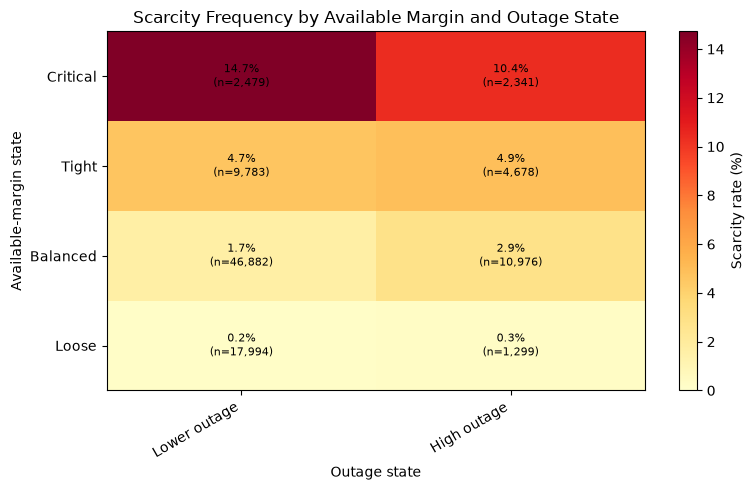

In [28]:
# ---------------------------------------------------------------------
# Available Margin and Outage Interaction
# ---------------------------------------------------------------------

margin_outage_summary = build_conditional_summary(
    scarcity_features["margin_state"], scarcity_features["outage_state"], primary_event
)

display(margin_outage_summary.round(3))

plot_conditional_heatmap(
    margin_outage_summary,
    row_order=MARGIN_STATE_ORDER,
    column_order=OUTAGE_STATE_ORDER,
    title="Scarcity Frequency by Available Margin and Outage State",
    row_label="Available-margin state",
    column_label="Outage state",
)

#### Margin State x Outages

Scarcity generally becomes more frequent when high outages occur alongside tight or balanced available margins. Under balanced conditions, the scarcity rate rises from 1.7% during lower-outage hours to 2.9% during high-outage hours. Under loose conditions, scarcity remains rare regardless of outage state.

An apparent reversal occurs within the critical-margin state: scarcity affects 14.7% of lower-outage hours compared with 10.4% of high-outage hours. This does not indicate that outages reduce scarcity. Available margin already reflects reported generation availability, so conditioning on critical margin compares different mechanisms through which the system became tight. Critical hours with lower outages may instead be driven by exceptionally high net load, weak renewable generation, import limitations, or other forms of supply pressure.

Overall, outages appear to increase scarcity primarily by contributing to tighter available margins. Once margins are already critical, other operating conditions may become more important than whether outage levels are unusually high.

### 6.3 Margin State × Intertie Capability

Intertie capability determines how much external support Alberta can access when domestic supply is tight. This comparison tests whether constrained import capability is associated with greater scarcity within the same available-margin state.

,row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,Critical,Constrained,824,0.175,11,8.977,8,31,True
1,Critical,Typical,2856,0.146,11,8.858,11,66,True
2,Critical,High capability,1140,0.041,10,0.074,9,37,True
3,Tight,Constrained,2622,0.088,11,2.944,11,58,True
4,Tight,Typical,8593,0.046,11,1.846,11,548,True
5,Tight,High capability,3246,0.017,11,0.124,10,144,True
6,Balanced,Constrained,10969,0.040,11,0.678,11,840,True
7,Balanced,Typical,35253,0.018,11,0.241,11,2696,True
8,Balanced,High capability,11636,0.003,11,0.042,11,579,True
9,Loose,Constrained,5000,0.004,11,0.000,11,212,True


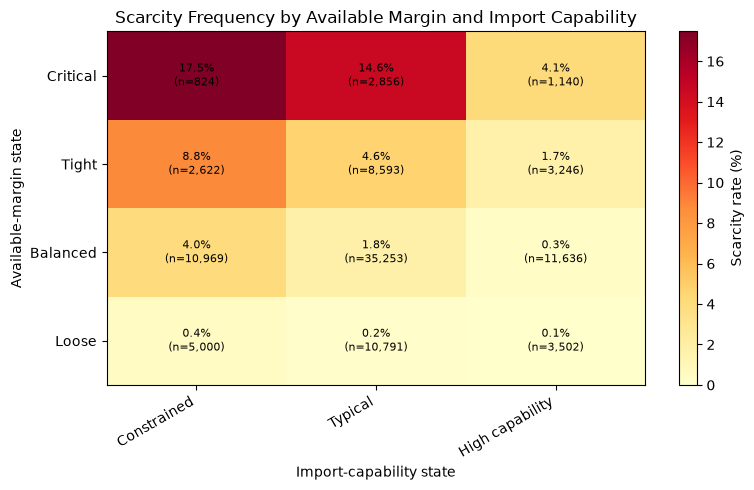

In [29]:
# ---------------------------------------------------------------------
# Available Margin and Import-Capability Interaction
# ---------------------------------------------------------------------

margin_capability_summary = build_conditional_summary(
    scarcity_features["margin_state"], scarcity_features["capability_state"], primary_event
)

display(margin_capability_summary.round(3))

plot_conditional_heatmap(
    margin_capability_summary,
    row_order=MARGIN_STATE_ORDER,
    column_order=CAPABILITY_STATE_ORDER,
    title="Scarcity Frequency by Available Margin and Import Capability",
    row_label="Available-margin state",
    column_label="Import-capability state",
)

#### Margin State x Intertie Capability

Scarcity is most frequent when limited domestic available margin coincides with constrained import capability. During critical-margin hours, the scarcity rate declines from 17.5% under constrained capability to 14.6% under typical capability and 4.1% under high capability. The same ordered relationship appears under tight margins, where scarcity falls from 8.8% to 4.6% and then 1.7% as capability improves.

Import capability remains informative under balanced conditions: scarcity affects 4.0% of constrained-capability hours, compared with 1.8% under typical capability and 0.3% when capability is high. Under loose domestic margins, scarcity remains below 0.5% regardless of external capability.

The median annual lifts reinforce this interaction. Critical margins combined with constrained or typical capability produce the strongest and most persistent elevation over annual base rates. Overall, domestic margin and import capability provide complementary indicators of system tightness, although the contemporaneous results do not establish that higher capability independently causes lower scarcity.

### 6.4 Net-Load Decile x Outage Decile

High outages may become more consequential when the system is also facing elevated net load. This comparison tests whether outage burden adds to scarcity risk across different levels of net-load pressure.

row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,0,176,0.000,11,NaN,1,63,False
0,1,289,0.000,11,0.000,5,28,True
0,2,515,0.000,11,0.000,10,26,True
0,3,656,0.000,11,0.000,11,27,True
0,4,788,0.000,11,0.000,11,49,True
0,5,1184,0.000,11,0.000,11,51,True
0,6,1250,0.000,11,0.000,11,85,True
0,7,1335,0.000,11,0.000,11,94,True
0,8,1543,0.000,11,0.000,11,77,True
0,9,1898,0.000,11,0.000,11,99,True


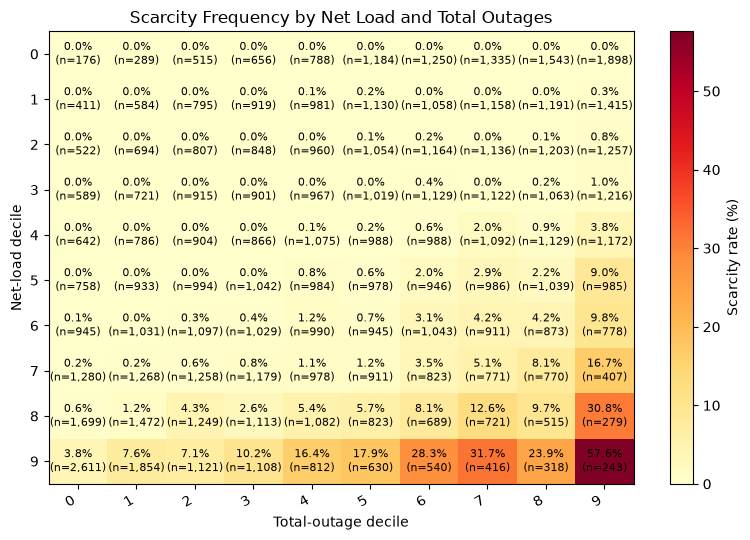

In [30]:
# ---------------------------------------------------------------------
# Net-Load and Outage Interaction
# ---------------------------------------------------------------------

from IPython.display import HTML

net_load_outage_summary = build_conditional_summary(
    scarcity_features["net_load_decile"], scarcity_features["total_outage_decile"], primary_event
)

display(HTML(
    f'<div style="max-height:500px;overflow:auto;">'
    f'{net_load_outage_summary.round(3).to_html(index=False)}</div>'
))

plot_conditional_heatmap(
    net_load_outage_summary,
    row_order=list(range(10)),
    column_order=list(range(10)),
    title="Scarcity Frequency by Net Load and Total Outages",
    row_label="Net-load decile",
    column_label="Total-outage decile",
)

#### Net-Load Decile x Outage Decile

Scarcity is strongly concentrated in hours when high net load coincides with elevated outages. Outages alone are not sufficient to produce scarcity: throughout the lower net-load deciles, scarcity remains close to zero even when outages are in their highest deciles. The outage relationship becomes increasingly pronounced as net load moves into its upper tail.

Within the highest net-load decile, the scarcity rate rises from 3.8% in the lowest outage decile to 28.3% in outage decile 6 and 57.9% when both variables are in their highest deciles. A similar interaction appears in net-load deciles 7 and 8, where scarcity becomes progressively more frequent as outages increase.

The highest joint state contains 242 pooled hours and appears in nine years, with a scarcity rate of 57.9%. However, only three years meet the minimum annual sample requirement, so a stable median annual lift is not reported for this cell. The result therefore provides strong pooled evidence of an interaction between high net load and high outages, but insufficient support for a precise claim about its annual stability.

### 6.5 Thermal-Headroom Decile x Import-Flow 

Imports may respond to domestic supply pressure rather than independently create it. This comparison examines how observed net imports vary with scarcity across thermal-headroom conditions, helping distinguish external support from the underlying domestic constraint.

row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,0,756,0.090,11,3.635,6,78,True
0,1,601,0.143,10,3.470,7,51,True
0,2,568,0.042,11,0.992,8,32,True
0,3,606,0.071,11,0.844,9,27,True
0,4,664,0.187,10,6.165,9,31,True
0,5,674,0.217,11,4.643,10,25,True
0,6,916,0.158,10,4.646,9,55,True
0,7,1241,0.239,11,7.448,11,29,True
0,8,1358,0.225,11,5.844,11,30,True
0,9,1553,0.251,11,12.622,11,37,True


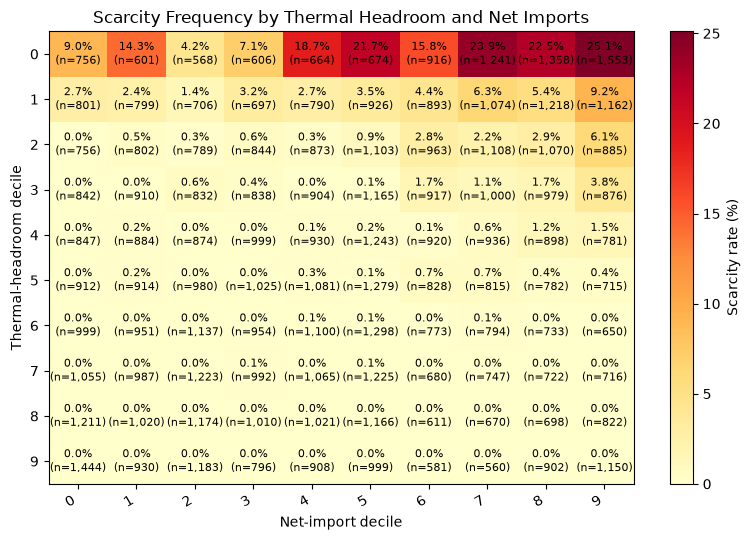

In [31]:
# ---------------------------------------------------------------------
# Thermal Headroom and Observed Import-Flow Interaction
# ---------------------------------------------------------------------

headroom_import_summary = build_conditional_summary(
    scarcity_features["thermal_headroom_decile"], scarcity_features["net_imports_decile"], primary_event
)

display(HTML(
    f'<div style="max-height:500px;overflow:auto;">'
    f'{headroom_import_summary.round(3).to_html(index=False)}</div>'
))

plot_conditional_heatmap(
    headroom_import_summary,
    row_order=list(range(10)),
    column_order=list(range(10)),
    title="Scarcity Frequency by Thermal Headroom and Net Imports",
    row_label="Thermal-headroom decile",
    column_label="Net-import decile",
)

#### Thermal-Headroom Decile x Import-Flow Decile

Scarcity is strongly concentrated in the lowest thermal-headroom deciles. When thermal headroom is in its lowest decile, scarcity rates range from 4.2% to 25.1% across net-import states. The highest joint rate occurs when thermal headroom is lowest and net imports are highest, producing a 25.1% scarcity rate and a median annual lift of 12.6.

Scarcity declines rapidly as thermal headroom improves. Even within the highest net-import decile, the scarcity rate falls from 25.1% in the lowest headroom decile to 9.2% in the second, 6.1% in the third, and effectively zero in the upper headroom deciles. This indicates that adequate thermal headroom is associated with very little scarcity regardless of observed import flow.

Higher imports do not correspond to lower contemporaneous scarcity within the most constrained headroom states. This likely reflects the endogenous nature of observed flows: imports increase in response to high Alberta prices and tight domestic supply. Imports may still mitigate scarcity, but this contemporaneous comparison cannot estimate what prices would have been without them.

### 6.6 Compact Feature Screening

ROC AUC is retained as a compact descriptive screening statistic, but it is not the notebook’s main evidence.

Each feature is evaluated using:

- overall ROC AUC;
- precision-recall AUC;
- top-tail scarcity lift;
- annual AUC interquartile range;
- annual direction consistency;
- structural-regime AUC; and
- available sample coverage.

Features expected to reduce scarcity when they increase are sign-adjusted before evaluation. These scores measure contemporaneous separation, not forecast performance.

In [32]:
# ---------------------------------------------------------------------
# Feature-Screening Helper
# ---------------------------------------------------------------------

def screen_feature(feature_name, values, direction, event):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "structural_regime": structural_regime,
        "value": values,
        "event": event,
    }).dropna()

    if direction not in {"higher", "lower"}:
        raise ValueError("direction must be 'higher' or 'lower'")

    score = frame["value"] if direction == "higher" else -frame["value"]
    overall_auc = roc_auc_score(frame["event"], score)
    precision_recall_auc = average_precision_score(frame["event"], score)
    scarcity_prevalence = frame["event"].mean()
    tail_event_rate = frame.loc[score.ge(score.quantile(0.90)), "event"].mean()
    top_tail_lift = tail_event_rate / scarcity_prevalence if scarcity_prevalence > 0 else np.nan

    annual_auc_values = []
    for _, group in frame.groupby("year_alberta"):
        if group["event"].nunique() < 2:
            continue
        group_score = group["value"] if direction == "higher" else -group["value"]
        annual_auc_values.append(roc_auc_score(group["event"], group_score))

    regime_auc_rows = []
    for regime, group in frame.groupby("structural_regime", observed=True):
        if group["event"].nunique() < 2:
            continue
        group_score = group["value"] if direction == "higher" else -group["value"]
        regime_auc_rows.append({
            "feature": feature_name,
            "structural_regime": regime,
            "roc_auc": roc_auc_score(group["event"], group_score),
            "observations": len(group),
        })

    annual_auc_values = np.asarray(annual_auc_values, dtype=float)

    overall_row = {
        "feature": feature_name,
        "expected_scarcity_direction": direction,
        "overall_roc_auc": overall_auc,
        "precision_recall_auc": precision_recall_auc,
        "overall_scarcity_prevalence": scarcity_prevalence,
        "pr_auc_lift_over_prevalence": precision_recall_auc / scarcity_prevalence if scarcity_prevalence > 0 else np.nan,
        "top_tail_scarcity_lift": top_tail_lift,
        "annual_auc_25th_percentile": np.nanquantile(annual_auc_values, 0.25),
        "annual_auc_75th_percentile": np.nanquantile(annual_auc_values, 0.75),
        "annual_direction_consistency_pct": np.mean(annual_auc_values >= 0.50) * 100,
        "coverage_pct": len(frame) / len(master) * 100,
    }

    return overall_row, regime_auc_rows

In [33]:
# ---------------------------------------------------------------------
# Screen Main Physical Driver Families
# ---------------------------------------------------------------------

SCREENING_FEATURES = {
    "Net load": (scarcity_features["net_load_mw"], "higher"),
    "Reported capacity margin": (scarcity_features["reported_capacity_margin_mw"], "lower"),
    "Domestic available margin": (scarcity_features["domestic_available_margin_mw"], "lower"),
    "Thermal headroom": (scarcity_features["thermal_headroom_mw"], "lower"),
    "Thermal utilization": (scarcity_features["thermal_utilization_pct"], "higher"),
    "Total outages": (master["total_outage_mw"], "higher"),
    "Relative outage burden": (scarcity_features["outage_share_of_capacity_pct"], "higher"),
    "Observed net imports": (master["net_imports_mw"], "higher"),
    "Reported import capability": (scarcity_features["import_atc_mw"], "lower"),
}

screening_rows, regime_auc_rows = [], []

for feature_name, (values, direction) in SCREENING_FEATURES.items():
    overall_row, feature_regime_rows = screen_feature(feature_name, values, direction, primary_event)
    screening_rows.append(overall_row)
    regime_auc_rows.extend(feature_regime_rows)

FEATURE_SCREENING_COLUMN_ORDER = [
    "feature", "expected_scarcity_direction", "overall_roc_auc",
    "precision_recall_auc", "overall_scarcity_prevalence",
    "pr_auc_lift_over_prevalence", "top_tail_scarcity_lift",
    "annual_auc_25th_percentile", "annual_auc_75th_percentile",
    "annual_direction_consistency_pct", "coverage_pct",
]

feature_screening = (
    pd.DataFrame(screening_rows)
    .sort_values("overall_roc_auc", ascending=False)
    .reset_index(drop=True)[FEATURE_SCREENING_COLUMN_ORDER]
)

regime_auc_screening = pd.DataFrame(regime_auc_rows)

display(feature_screening.round(3))
display(
    regime_auc_screening
    .pivot(index="feature", columns="structural_regime", values="roc_auc")
    .reindex(columns=STRUCTURAL_REGIME_ORDER)
    .round(3)
)

,feature,expected_scarcity_direction,overall_roc_auc,precision_recall_auc,overall_scarcity_prevalence,pr_auc_lift_over_prevalence,top_tail_scarcity_lift,annual_auc_25th_percentile,annual_auc_75th_percentile,annual_direction_consistency_pct,coverage_pct
0,Thermal headroom,lower,0.898,0.183,0.025,7.263,6.082,0.917,0.980,100.000,100.000
1,Thermal utilization,higher,0.876,0.143,0.025,5.679,5.053,0.928,0.968,100.000,100.000
2,Net load,higher,0.828,0.148,0.025,5.858,4.448,0.815,0.900,100.000,100.000
3,Observed net imports,higher,0.754,0.053,0.025,2.113,2.197,0.703,0.833,100.000,96.191
4,Total outages,higher,0.633,0.039,0.025,1.538,1.526,0.595,0.788,100.000,100.000
5,Reported import capability,lower,0.614,0.045,0.025,1.782,2.119,0.416,0.707,63.636,100.000
6,Relative outage burden,higher,0.601,0.037,0.025,1.453,1.514,0.570,0.790,100.000,100.000
7,Domestic available margin,lower,0.585,0.049,0.025,1.959,2.431,0.820,0.956,100.000,100.000
8,Reported capacity margin,lower,0.527,0.044,0.025,1.755,1.654,0.675,0.794,100.000,100.000


structural_regime,Coal-dominant,Coal-to-gas transition,Late coal exit and renewable buildout,Coal-free gas-renewable system
feature,,,,
Domestic available margin,0.904,0.893,0.738,0.843
Net load,0.762,0.862,0.849,0.880
Observed net imports,0.919,0.743,0.730,0.926
Relative outage burden,0.833,0.654,0.585,0.695
Reported capacity margin,0.682,0.770,0.685,0.664
Reported import capability,0.518,0.489,0.622,0.776
Thermal headroom,0.904,0.925,0.943,0.951
Thermal utilization,0.855,0.921,0.939,0.960
Total outages,0.827,0.660,0.507,0.695


In [34]:
# ---------------------------------------------------------------------
# Test Thermal-Headroom Sensitivity to Dual-Fuel Reporting Gap
# ---------------------------------------------------------------------

thermal_headroom_sensitivity_frame = pd.DataFrame({
    "event": primary_event,
    "thermal_headroom_mw": scarcity_features["thermal_headroom_mw"],
    "dual_fuel_reporting_gap": scarcity_features["dual_fuel_reporting_gap"],
}).dropna(subset=["event", "thermal_headroom_mw"])

complete_sample_auc = roc_auc_score(
    thermal_headroom_sensitivity_frame["event"],
    -thermal_headroom_sensitivity_frame["thermal_headroom_mw"],
)

gap_excluded_frame = thermal_headroom_sensitivity_frame.loc[
    ~thermal_headroom_sensitivity_frame["dual_fuel_reporting_gap"]
]

gap_excluded_auc = roc_auc_score(
    gap_excluded_frame["event"],
    -gap_excluded_frame["thermal_headroom_mw"],
)

thermal_headroom_sensitivity = pd.DataFrame([
    {
        "sample": "Complete sample",
        "observations": len(thermal_headroom_sensitivity_frame),
        "scarcity_hours": int(thermal_headroom_sensitivity_frame["event"].sum()),
        "thermal_headroom_roc_auc": complete_sample_auc,
    },
    {
        "sample": "Excluding dual-fuel reporting gap",
        "observations": len(gap_excluded_frame),
        "scarcity_hours": int(gap_excluded_frame["event"].sum()),
        "thermal_headroom_roc_auc": gap_excluded_auc,
    },
])

thermal_headroom_sensitivity["change_from_complete_sample"] = (
    thermal_headroom_sensitivity["thermal_headroom_roc_auc"] - complete_sample_auc
)

display(thermal_headroom_sensitivity.round(3))

,sample,observations,scarcity_hours,thermal_headroom_roc_auc,change_from_complete_sample
0,Complete sample,96432,2430,0.898,0.000
1,Excluding dual-fuel reporting gap,90649,1973,0.899,0.001


#### Compact Feature Screening

Thermal headroom is the strongest individual scarcity indicator. It produces an overall ROC-AUC of 0.898, a precision-recall AUC of 0.183 against a no-skill prevalence of 0.025, and a high-risk-tail scarcity lift of 6.08. Its precision-recall performance is therefore approximately 7.3 times the no-skill reference level. Its direction is consistent in every year, and its regime-specific ROC-AUC remains above 0.90 across all four structural regimes. Because technology classifications and reporting coverage change over time, differences in ROC-AUC magnitude across regimes should not be interpreted as evidence that the physical relationship itself progressively strengthened. Thermal utilization provides similarly strong and stable separation. Net load ranks third, with an overall ROC-AUC of 0.828 and consistently strong performance across structural regimes.

Observed net imports provide moderate discrimination, with an overall ROC-AUC of 0.754. However, observed flows can respond contemporaneously to system conditions and should not be interpreted as an independently causal or automatically forecast-eligible signal. Total outages and relative outage burden provide weaker separation, and their performance varies across regimes. Most notably, the ROC-AUC for total outages falls to approximately 0.51 during the late coal-exit and renewable-buildout period, indicating almost no unconditional separation within that regime.

Domestic available margin presents an important aggregation result. Its pooled ROC-AUC is only 0.585, despite substantially stronger annual and regime-specific scores. This divergence is consistent with long-term shifts in fleet composition, availability reporting, variable scale, and scarcity incidence obscuring the within-period relationship when all years are pooled. Reported capacity margin displays a similar but weaker discrepancy between pooled and within-period performance. Reported import capability is the least stable indicator, matching its expected scarcity direction in only 63.6% of evaluated years.

Overall, operational measures of thermal tightness and net load provide substantially stronger and more stable scarcity separation than reported capacity, outages, or import capability alone. These results are descriptive and contemporaneous: they measure how well individual variables separate scarcity from non-scarcity hours in the observed sample, not causal effects or out-of-sample forecasting performance.

Dual-fuel reporting is missing for 5,783 hours from March 8 through November 4, 2022. Because the thermal aggregation uses the available technology-level observations without imputing missing values, dual-fuel availability and generation are omitted from the reported thermal totals during this interval.

Excluding the affected hours changes thermal headroom’s ROC-AUC only from 0.898 to 0.899. The primary conclusion is therefore robust to the dual-fuel reporting gap. The affected observations remain flagged because the reported thermal totals are not fully comparable during that interval, but no synthetic dual-fuel values are introduced.

## 7. Scarcity Episodes and Event Persistence

### 7.1 Consecutive Scarcity Episodes

Consecutive hours at or above \$500/MWh are grouped into scarcity episodes. This prevents a multi-hour event from being treated as several unrelated observations.

Episodes are summarized by duration, peak price, integrated price excess, load, available margin, thermal headroom, outages, and imports.

In [35]:
# ---------------------------------------------------------------------
# Test Thermal-Headroom Sensitivity to Dual-Fuel Reporting Gap
# ---------------------------------------------------------------------

thermal_headroom_sensitivity_frame = pd.DataFrame({
    "event": primary_event,
    "thermal_headroom_mw": scarcity_features["thermal_headroom_mw"],
    "dual_fuel_reporting_gap": scarcity_features["dual_fuel_reporting_gap"],
}).dropna(subset=["event", "thermal_headroom_mw"])

complete_sample_auc = roc_auc_score(
    thermal_headroom_sensitivity_frame["event"],
    -thermal_headroom_sensitivity_frame["thermal_headroom_mw"],
)

gap_excluded_frame = thermal_headroom_sensitivity_frame.loc[
    ~thermal_headroom_sensitivity_frame["dual_fuel_reporting_gap"]
]

gap_excluded_auc = roc_auc_score(
    gap_excluded_frame["event"],
    -gap_excluded_frame["thermal_headroom_mw"],
)

thermal_headroom_sensitivity = pd.DataFrame([
    {
        "sample": "Complete sample",
        "observations": len(thermal_headroom_sensitivity_frame),
        "scarcity_hours": int(thermal_headroom_sensitivity_frame["event"].sum()),
        "thermal_headroom_roc_auc": complete_sample_auc,
    },
    {
        "sample": "Excluding dual-fuel reporting gap",
        "observations": len(gap_excluded_frame),
        "scarcity_hours": int(gap_excluded_frame["event"].sum()),
        "thermal_headroom_roc_auc": gap_excluded_auc,
    },
])

thermal_headroom_sensitivity["change_from_complete_sample"] = (
    thermal_headroom_sensitivity["thermal_headroom_roc_auc"] - complete_sample_auc
)

display(thermal_headroom_sensitivity.round(3))

,sample,observations,scarcity_hours,thermal_headroom_roc_auc,change_from_complete_sample
0,Complete sample,96432,2430,0.898,0.000
1,Excluding dual-fuel reporting gap,90649,1973,0.899,0.001


#### Consecutive Scarcity Episodes

The hourly scarcity observations form 758 distinct consecutive episodes. The most severe episodes are not isolated one-hour price spikes: the leading events generally persist for 10–25 consecutive hours, with average prices frequently exceeding $800/MWh and peak prices approaching the historical price cap.

The largest cumulative event occurred in December 2021, lasting 17 hours with an average price of $933.53/MWh. Other major episodes cluster in January 2020, summer and winter 2022, summer 2023, and January 2024. Several occur on successive days, indicating that prolonged system stress can produce repeated episodes separated by brief periods below the scarcity threshold.

High net load and limited thermal headroom are common across the most severe episodes, but outage and import conditions vary substantially. Some events coincide with high outages and limited imports, while others receive considerable external support. This variation indicates that Alberta’s most consequential scarcity episodes arise through multiple combinations of demand pressure, domestic availability, renewable output, outages, and intertie flows.

### 7.2 Frequency, Duration, and Persistence

The annual view helps distinguish years characterized by many short scarcity events from those dominated by fewer, more persistent episodes.

In [36]:
# ---------------------------------------------------------------------
# Summarize episode frequency and persistence
# ---------------------------------------------------------------------
annual_episode_summary = (
    scarcity_episodes.groupby("start_year")
    .agg(
        episodes=("duration_hours", "size"),
        scarcity_hours=("duration_hours", "sum"),
        average_duration_hours=("duration_hours", "mean"),
        median_duration_hours=("duration_hours", "median"),
        maximum_duration_hours=("duration_hours", "max"),
        maximum_episode_price=("peak_price", "max"),
        integrated_price_excess=("integrated_price_excess", "sum"),
    )
)

display(annual_episode_summary.round(2))

NameError: name 'scarcity_episodes' is not defined

#### Frequency, Duration, and Persistence

Scarcity changed in both frequency and persistence over the study period. Events were exceptionally uncommon in 2016 and 2017, followed by a moderate increase during 2018–2019. Although 2020 contained only 20 episodes, they lasted an average of 5.1 hours—the longest annual average in the sample—showing that relatively infrequent scarcity can still produce prolonged system stress.

Scarcity intensified sharply after 2020. The number of episodes increased to 95 in 2021 and approximately 200 in both 2022 and 2023. Conditions were most severe in 2022, with 758 scarcity hours, a maximum episode duration of 25 hours, and the highest integrated price excess in the sample at approximately 179,566 $(\$/\mathrm{MWh}) \times \mathrm{hours}$. Although 2023 recorded slightly more episodes, they were shorter and produced fewer scarcity hours and lower integrated price excess.

Conditions moderated in 2024 and 2025, but scarcity remained more frequent than during most of the pre-2021 period. The annual maximum price reached or approached $1,000/MWh in nearly every year, making episode frequency, duration, and integrated price excess more informative measures of annual severity than the maximum price alone.

### 7.3 Event-Aligned Operating Profiles

Each episode is aligned at its first \$500/MWh hour. Median and interquartile-range profiles are calculated from 24 hours before onset through 12 hours afterward.

These profiles help distinguish three types of relationship:

- variables that deteriorate before the event;
- variables that change concurrently with event onset; and
- variables that respond only after scarcity is already underway.

The profiles remain descriptive because they use final contemporaneous observations.

In [ ]:
# ---------------------------------------------------------------------
# Align physical variables around scarcity onset
# ---------------------------------------------------------------------
EVENT_WINDOW_START, EVENT_WINDOW_END = -24, 12
onset_positions = np.flatnonzero(episode_start.to_numpy())

aligned_variables = {
    "Pool price": master["pool_price"],
    "Net load": scarcity_features["net_load_mw"],
    "Domestic available margin": scarcity_features["domestic_available_margin_mw"],
    "Thermal headroom": scarcity_features["thermal_headroom_mw"],
    "Total outages": master["total_outage_mw"],
    "Wind generation": master["wind_system_generation"],
    "Net imports": master["net_imports_mw"],
}

aligned_rows = []
for episode_number, onset_position in enumerate(onset_positions, start=1):
    start_position, end_position = onset_position + EVENT_WINDOW_START, onset_position + EVENT_WINDOW_END
    if start_position < 0 or end_position >= len(master):
        continue

    aligned_block = pd.DataFrame({
        name: values.iloc[start_position:end_position + 1].to_numpy()
        for name, values in aligned_variables.items()
    })
    aligned_block["episode_number"] = episode_number
    aligned_block["relative_hour"] = np.arange(EVENT_WINDOW_START, EVENT_WINDOW_END + 1)
    aligned_rows.append(aligned_block)

event_aligned = pd.concat(aligned_rows, ignore_index=True)
event_aligned_long = event_aligned.melt(
    id_vars=["episode_number", "relative_hour"], var_name="variable", value_name="value"
)

event_aligned_profile = (
    event_aligned_long.groupby(["variable", "relative_hour"])["value"]
    .agg(
        median="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        observations="count",
    )
    .reset_index()
)

display(event_aligned_profile.head())

,variable,relative_hour,median,q25,q75,observations
0,Domestic available margin,-24,3236.0,2081.50,4395.00,758
1,Domestic available margin,-23,3167.5,2088.75,4437.00,758
2,Domestic available margin,-22,3165.5,2081.75,4444.75,758
3,Domestic available margin,-21,3197.5,2149.50,4471.00,758
4,Domestic available margin,-20,3254.0,2192.00,4563.50,758


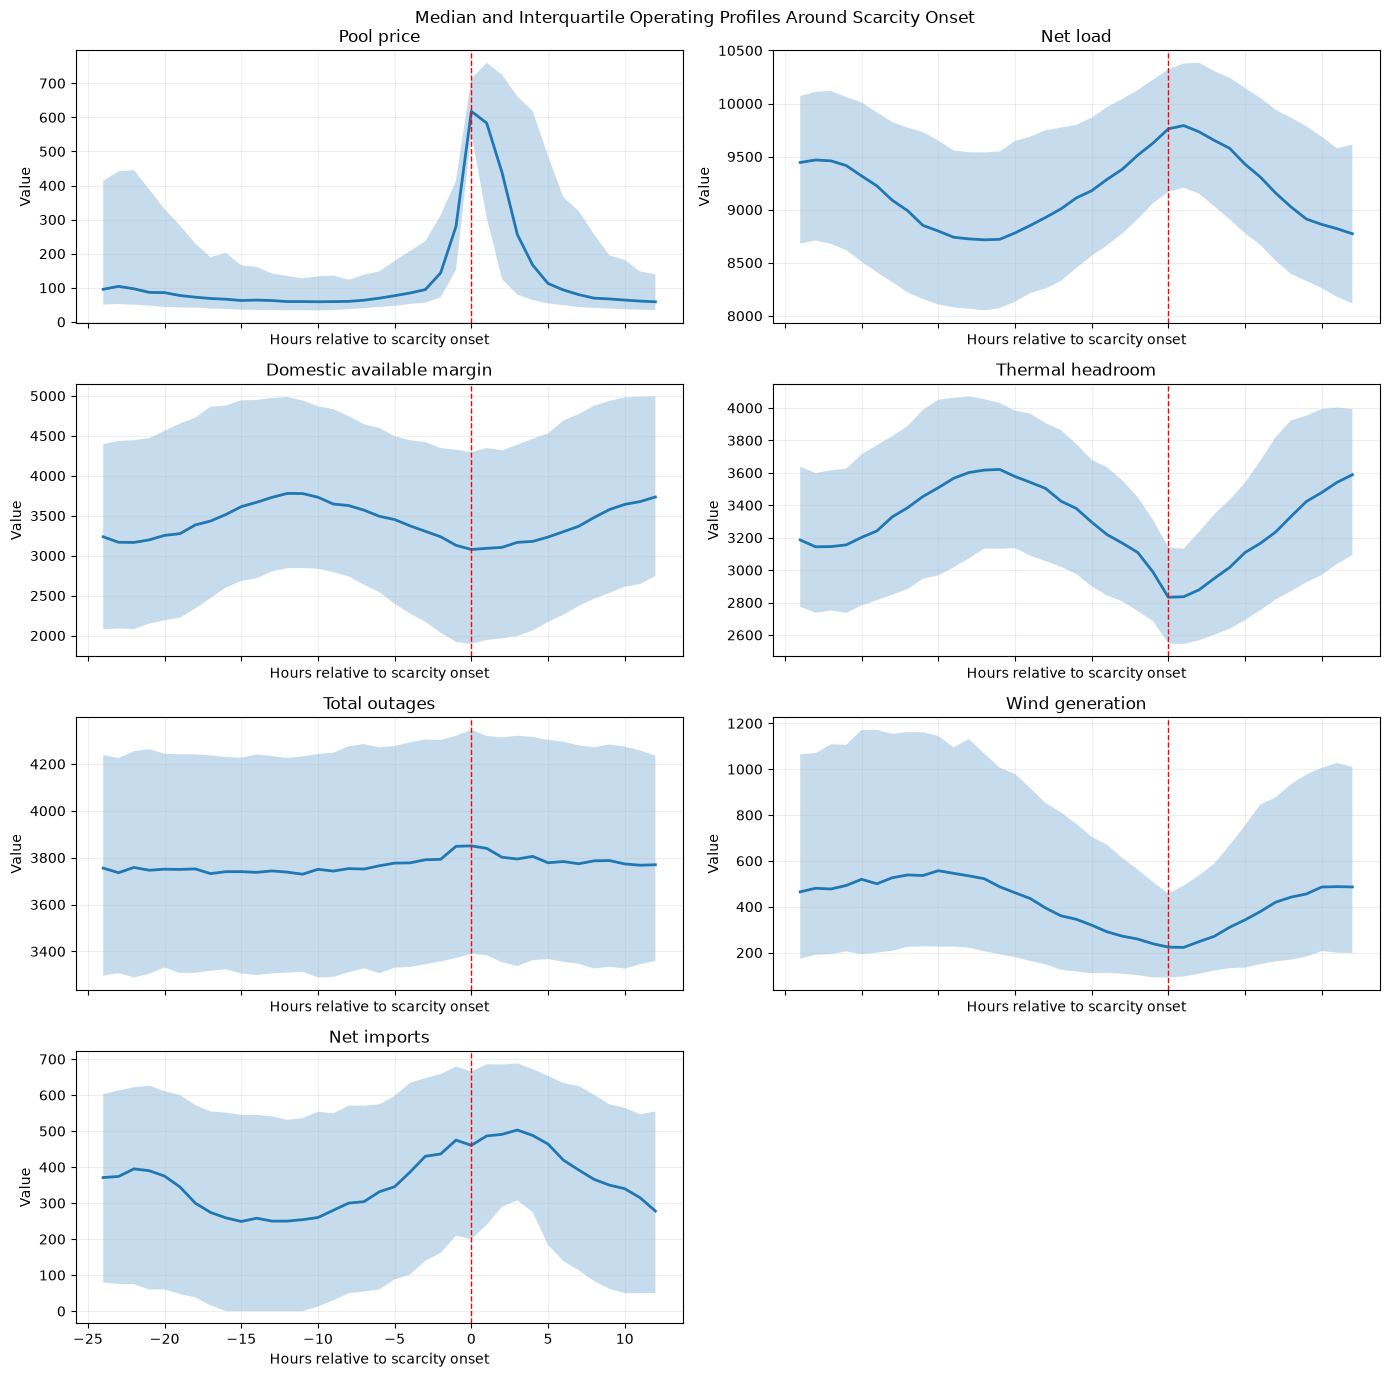

In [ ]:
# ---------------------------------------------------------------------
# Plot median and interquartile event-aligned profiles
# ---------------------------------------------------------------------
profile_variables = list(aligned_variables)
fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
axes = axes.flatten()

for axis, variable in zip(axes, profile_variables):
    plot_data = event_aligned_profile[event_aligned_profile["variable"].eq(variable)]
    axis.plot(plot_data["relative_hour"], plot_data["median"], linewidth=2)
    axis.fill_between(plot_data["relative_hour"], plot_data["q25"], plot_data["q75"], alpha=0.25)
    axis.axvline(0, color="red", linestyle="--", linewidth=1)
    axis.set(title=variable, xlabel="Hours relative to scarcity onset", ylabel="Value")
    axis.grid(alpha=0.20)

for axis in axes[len(profile_variables):]:
    axis.set_visible(False)

fig.suptitle("Median and Interquartile Operating Profiles Around Scarcity Onset")
plt.tight_layout()
plt.show()

#### Event-Aligned Operating Profiles

The 24-hour profiles around 758 scarcity onsets show a coordinated tightening of Alberta’s operating position. Net load rises steadily before onset and reaches its highest median level shortly afterward. Over the same period, wind generation declines, domestic available margin contracts, and thermal headroom falls sharply toward its minimum.

Observed net imports increase as domestic conditions tighten, rising before onset and peaking several hours afterward. This timing is consistent with imports responding to Alberta’s emerging supply pressure and elevated prices. Total outages, by contrast, change relatively little around onset, showing only a modest increase compared with the pronounced movements in net load and thermal headroom.

Pool price rises abruptly immediately before the event threshold is crossed and remains elevated during the first several scarcity hours before declining. Overall, the median episode develops through rising net demand, weakening renewable output, falling domestic and thermal margins, and increasing external support. The wide interquartile ranges indicate substantial variation across individual episodes, so these profiles describe the typical sequence rather than a universal event pathway.

### 7.4 Historical Case Studies

The most severe episodes are examined individually to determine whether they share a common physical profile or represent different scarcity mechanisms.

Severity is ranked by integrated price excess above \$500/MWh, followed by episode duration and peak price.

In [ ]:
# ---------------------------------------------------------------------
# Plot a selected scarcity episode case study
# ---------------------------------------------------------------------

def plot_episode_case_study(selected_episode_id, hours_before=24, hours_after=24):
    selected = scarcity_episodes.loc[selected_episode_id]
    window_start = selected["start"] - pd.Timedelta(hours=hours_before)
    window_end = selected["end"] + pd.Timedelta(hours=hours_after)
    window_mask = master["timestamp_alberta"].between(window_start, window_end)

    window = pd.DataFrame({
        "timestamp": master.loc[window_mask, "timestamp_alberta"],
        "pool_price": master.loc[window_mask, "pool_price"],
        "available_margin": scarcity_features.loc[window_mask, "domestic_available_margin_mw"],
        "thermal_headroom": scarcity_features.loc[window_mask, "thermal_headroom_mw"],
        "total_outages": master.loc[window_mask, "total_outage_mw"],
        "net_imports": master.loc[window_mask, "net_imports_mw"],
    })

    fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

    axes[0].plot(window["timestamp"], window["pool_price"])
    axes[0].axhline(PRIMARY_SCARCITY_THRESHOLD, linestyle="--", linewidth=1)
    axes[0].set_ylabel("Price\n($/MWh)")

    axes[1].plot(window["timestamp"], window["available_margin"], label="Available margin")
    axes[1].plot(window["timestamp"], window["thermal_headroom"], label="Thermal headroom")
    axes[1].set_ylabel("Margin\n(MW)")
    axes[1].legend()

    axes[2].plot(window["timestamp"], window["total_outages"])
    axes[2].set_ylabel("Outages\n(MW)")

    axes[3].plot(window["timestamp"], window["net_imports"])
    axes[3].axhline(0, linewidth=1)
    axes[3].set(xlabel="Alberta timestamp", ylabel="Net imports\n(MW)")

    for axis in axes:
        axis.axvspan(selected["start"], selected["end"], color="red", alpha=0.15)
        axis.grid(alpha=0.20)

    fig.suptitle(f"Scarcity Episode Beginning {selected['start']}")
    plt.tight_layout()
    plt.show()

    episode_summary = scarcity_episodes.loc[[selected_episode_id]].copy()
    numeric_columns = episode_summary.select_dtypes(include="number").columns
    episode_summary[numeric_columns] = episode_summary[numeric_columns].round(2)

    display(episode_summary)

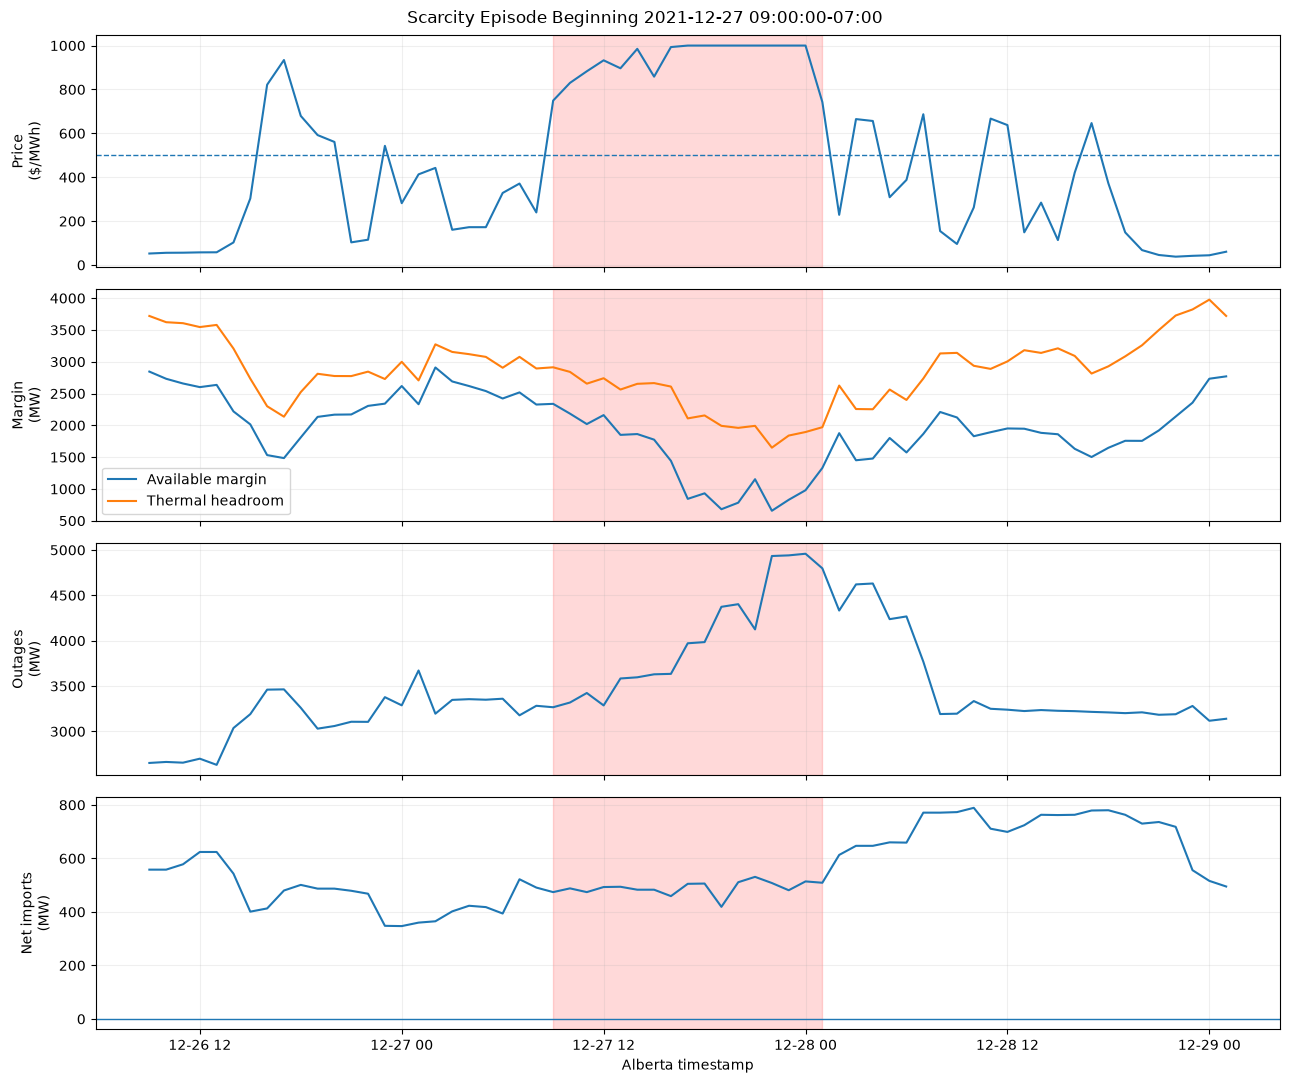

,start,end,duration_hours,peak_price,average_price,integrated_price_excess,peak_load_mw,peak_net_load_mw,minimum_available_margin_mw,minimum_thermal_headroom_mw,maximum_total_outage_mw,average_net_imports_mw,start_year
episode_id,,,,,,,,,,,,,
236.0,2021-12-27 09:00:00-07:00,2021-12-28 01:00:00-07:00,17,999.99,933.53,7370.07,11508,10951.94,657.0,1649.08,4958.4,490.12,2021


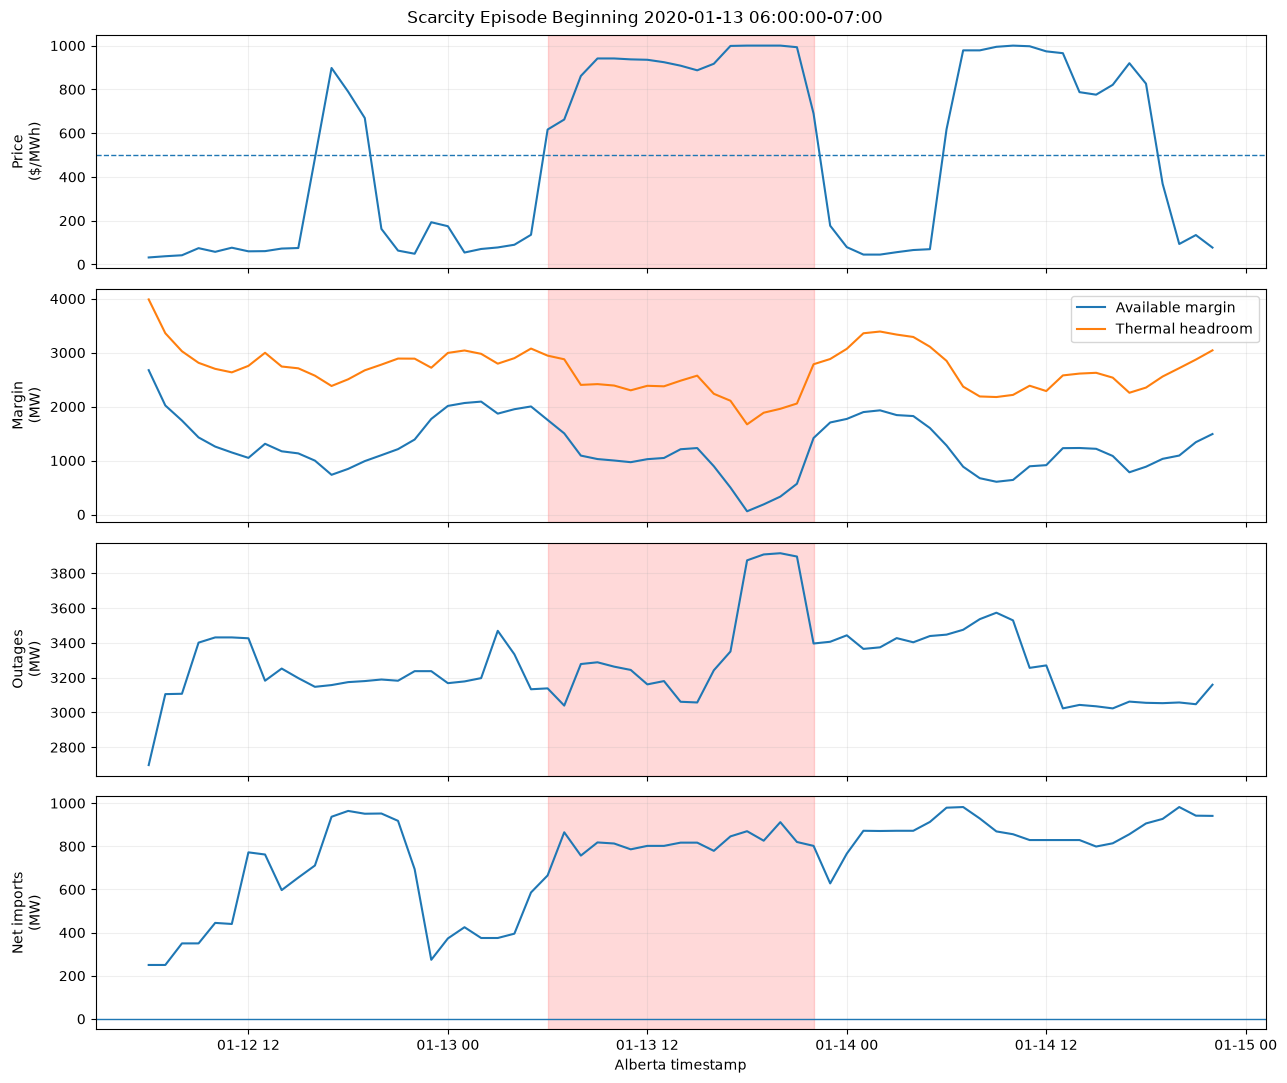

,start,end,duration_hours,peak_price,average_price,integrated_price_excess,peak_load_mw,peak_net_load_mw,minimum_available_margin_mw,minimum_thermal_headroom_mw,maximum_total_outage_mw,average_net_imports_mw,start_year
episode_id,,,,,,,,,,,,,
129.0,2020-01-13 06:00:00-07:00,2020-01-13 22:00:00-07:00,17,999.99,894.8,6711.55,11693,11627.94,60.0,1671.34,3915.4,811.59,2020


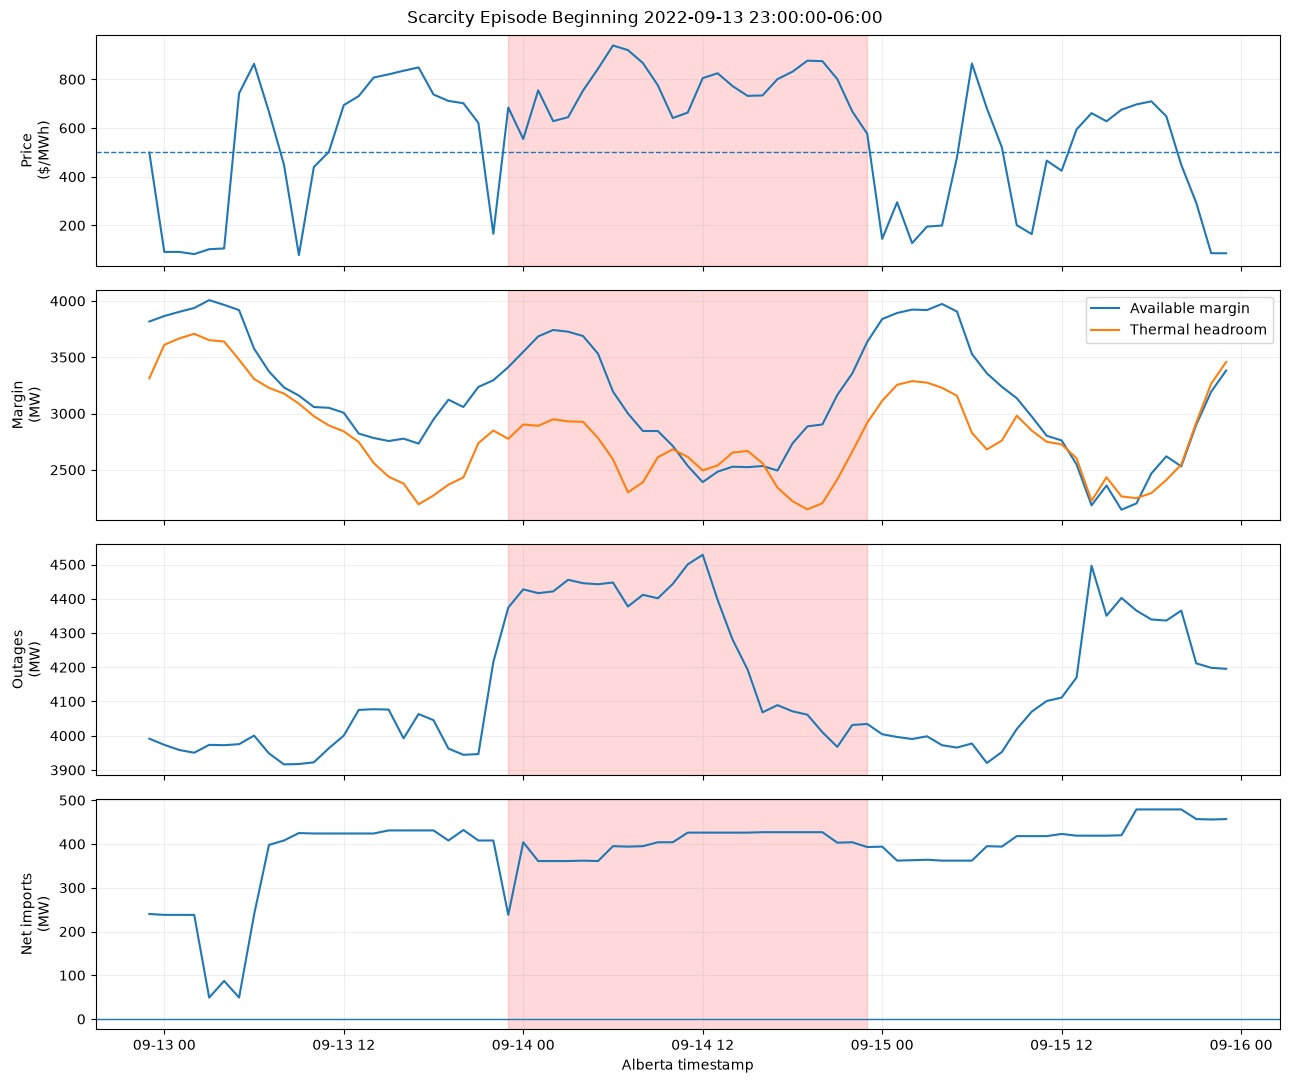

,start,end,duration_hours,peak_price,average_price,integrated_price_excess,peak_load_mw,peak_net_load_mw,minimum_available_margin_mw,minimum_thermal_headroom_mw,maximum_total_outage_mw,average_net_imports_mw,start_year
episode_id,,,,,,,,,,,,,
337.0,2022-09-13 23:00:00-06:00,2022-09-14 23:00:00-06:00,25,938.95,758.62,6465.41,9994,9538.08,2391.0,2148.59,4528.4,396.2,2022


In [ ]:
# ---------------------------------------------------------------------
# Plot the three most severe historical episodes
# ---------------------------------------------------------------------

for selected_episode_id in scarcity_episodes.head(3).index:
    plot_episode_case_study(selected_episode_id)

#### Historical Case Studies

The three most severe episodes illustrate that prolonged scarcity can emerge through different combinations—and sequences—of system pressure.

The December 2021 episode combined extremely high prices with a severe deterioration in domestic supply conditions. During the 17-hour event, average price reached $933.53/MWh, available margin fell to 657 MW, thermal headroom declined to 1,649 MW, and outages approached 4,958 MW. The most severe price conditions broadly coincided with collapsing headroom and rising outages. Imports remained substantial during the event and increased further afterward as domestic margins began recovering.

The January 2020 episode represents the most acute available-margin constraint. Available margin fell to only 60 MW while thermal headroom declined to 1,671 MW. Outages rose sharply near the period of greatest margin compression, while pool price approached the price cap. Alberta averaged approximately 812 MW of net imports throughout the 17-hour event, indicating considerable reliance on external supply. A second major price increase followed shortly afterward, placing the episode within a broader period of persistent market stress.

The September 2022 episode followed a different sequence. Scarcity began while outages were already elevated but thermal headroom had not yet reached its minimum. As the 25-hour episode progressed, outages declined while thermal headroom continued to collapse, allowing scarcity to persist even as the initial outage pressure eased. Minimum available margin remained near 2,391 MW and thermal headroom near 2,149 MW—less extreme than in the winter cases—yet prices remained above the scarcity threshold for longer.

This contrast is analytically important. In the 2020 and 2021 episodes, peak scarcity aligned more directly with simultaneous margin compression, low thermal headroom, and elevated outages. In September 2022, the condition sustaining scarcity changed during the event: high outages were prominent at onset, while declining thermal headroom became more important later.

Together, the cases reinforce that thermal headroom and available margin are important scarcity indicators while also showing that no single threshold or static operating condition explains every severe episode. Duration and severity depend not only on the combination of domestic availability, outages, net demand, imports, and structural regime, but also on how those conditions evolve throughout an event.

## 8. Evidence Register

The notebook concludes with a compact evidence register. Each driver is assessed on:

1. **Direction** — how it relates to scarcity.
2. **Shape** — whether the relationship is linear, threshold-based, or concentrated in the tail.
3. **Incrementality** — whether it remains informative after conditioning on net load or system margin.
4. **Interactions** — the operating conditions under which it matters most.
5. **Stability** — whether the relationship persists across years and structural regimes.
6. **Timing** — whether the information would be available before the forecast hour.
7. **Redundancy** — whether it adds information beyond related variables.
8. **Event value** — whether it helps characterize scarcity onset, severity, or persistence.

The register distinguishes **descriptive value** from **forecast eligibility**. A strong contemporaneous relationship does not necessarily make a variable forecast-ready.

In [ ]:
# ---------------------------------------------------------------------
# Create the compact evidence register
# ---------------------------------------------------------------------
evidence_metadata = pd.DataFrame([
    {"feature": "Net load", "mechanism": "Demand remaining after wind and solar",
     "conditional_on": "Available margin and outages", "forecast_eligibility": "Requires load and renewable forecasts",
     "redundant_with": pd.NA, "feature_role": "Primary", "destination": "Retain"},
    {"feature": "Reported capacity margin", "mechanism": "Nominal fleet size relative to load",
     "conditional_on": "Structural regime", "forecast_eligibility": "Constructible from capacity and load forecasts",
     "redundant_with": pd.NA, "feature_role": "Benchmark", "destination": "Benchmark"},
    {"feature": "Domestic available margin", "mechanism": "Reported available supply relative to load",
     "conditional_on": "Structural regime", "forecast_eligibility": "Requires forecast-vintage availability",
     "redundant_with": pd.NA, "feature_role": "Primary", "destination": "Retain"},
    {"feature": "Thermal headroom", "mechanism": "Unused reported thermal availability",
     "conditional_on": "Net load and available margin", "forecast_eligibility": "Descriptive unless commitment is forecast",
     "redundant_with": "Thermal utilization", "feature_role": "Primary", "destination": "Conditional"},
    {"feature": "Thermal utilization", "mechanism": "Intensity of thermal fleet use",
     "conditional_on": "Net load and available margin", "forecast_eligibility": "Descriptive unless dispatch is forecast",
     "redundant_with": "Thermal headroom", "feature_role": "Supporting", "destination": "Conditional"},
    {"feature": "Total outages", "mechanism": "Unavailable generation",
     "conditional_on": "Available margin and net load", "forecast_eligibility": "Depends on outage-data vintage",
     "redundant_with": "Relative outage burden", "feature_role": "Primary", "destination": "Conditional"},
    {"feature": "Relative outage burden", "mechanism": "Outages relative to fleet size",
     "conditional_on": "Available margin", "forecast_eligibility": "Depends on outage-data vintage",
     "redundant_with": "Total outages", "feature_role": "Supporting", "destination": "Conditional"},
    {"feature": "Observed net imports", "mechanism": "External support responding to system stress",
     "conditional_on": "Margin and import capability", "forecast_eligibility": "Requires an import forecast",
     "redundant_with": pd.NA, "feature_role": "Descriptive", "destination": "Descriptive only"},
    {"feature": "Reported import capability", "mechanism": "Maximum reported external import support",
     "conditional_on": "Margin and regional conditions", "forecast_eligibility": "Requires forecast-vintage capability",
     "redundant_with": pd.NA, "feature_role": "Primary", "destination": "Conditional"},
])

evidence_register = evidence_metadata.merge(feature_screening, on="feature", how="left")
evidence_register["annual_auc_iqr"] = (
    evidence_register["annual_auc_75th_percentile"] - evidence_register["annual_auc_25th_percentile"]
)

evidence_register = evidence_register[[
    "feature", "mechanism", "expected_scarcity_direction", "overall_roc_auc", "precision_recall_auc",
    "overall_scarcity_prevalence", "pr_auc_lift_over_prevalence", "top_tail_scarcity_lift", "annual_auc_iqr",
    "annual_direction_consistency_pct", "coverage_pct", "conditional_on", "forecast_eligibility",
    "redundant_with", "feature_role", "destination",
]]

display(evidence_register.round(3))

,feature,mechanism,expected_scarcity_direction,overall_roc_auc,precision_recall_auc,overall_scarcity_prevalence,pr_auc_lift_over_prevalence,top_tail_scarcity_lift,annual_auc_iqr,annual_direction_consistency_pct,coverage_pct,conditional_on,forecast_eligibility,redundant_with,feature_role,destination
0,Net load,Demand remaining after wind and solar,higher,0.828,0.148,0.025,5.858,4.448,0.085,100.000,100.000,Available margin and outages,Requires load and renewable forecasts,NaN,Primary,Retain
1,Reported capacity margin,Nominal fleet size relative to load,lower,0.527,0.044,0.025,1.755,1.654,0.120,100.000,100.000,Structural regime,Constructible from capacity and load forecasts,NaN,Benchmark,Benchmark
2,Domestic available margin,Reported available supply relative to load,lower,0.585,0.049,0.025,1.959,2.431,0.137,100.000,100.000,Structural regime,Requires forecast-vintage availability,NaN,Primary,Retain
3,Thermal headroom,Unused reported thermal availability,lower,0.898,0.183,0.025,7.263,6.082,0.063,100.000,100.000,Net load and available margin,Descriptive unless commitment is forecast,Thermal utilization,Primary,Conditional
4,Thermal utilization,Intensity of thermal fleet use,higher,0.876,0.143,0.025,5.679,5.053,0.040,100.000,100.000,Net load and available margin,Descriptive unless dispatch is forecast,Thermal headroom,Supporting,Conditional
5,Total outages,Unavailable generation,higher,0.633,0.039,0.025,1.538,1.526,0.194,100.000,100.000,Available margin and net load,Depends on outage-data vintage,Relative outage burden,Primary,Conditional
6,Relative outage burden,Outages relative to fleet size,higher,0.601,0.037,0.025,1.453,1.514,0.219,100.000,100.000,Available margin,Depends on outage-data vintage,Total outages,Supporting,Conditional
7,Observed net imports,External support responding to system stress,higher,0.754,0.053,0.025,2.113,2.197,0.130,100.000,96.191,Margin and import capability,Requires an import forecast,NaN,Descriptive,Descriptive only
8,Reported import capability,Maximum reported external import support,lower,0.614,0.045,0.025,1.782,2.119,0.290,63.636,100.000,Margin and regional conditions,Requires forecast-vintage capability,NaN,Primary,Conditional


#### Evidence Register

The feature assessment separates historical scarcity discrimination from genuine forecast eligibility. Thermal headroom and thermal utilization provide the strongest contemporaneous separation, with ROC-AUC values of 0.898 and 0.876 and high-risk-tail lifts of 6.08 and 5.05. They are also highly stable across years. However, both depend on contemporaneous availability, commitment, and dispatch information, so they should remain conditional or descriptive unless those quantities can be forecast at the intended prediction origin.

Net load offers the strongest combination of discrimination, stability, and practical forecasting potential. It achieves an overall ROC-AUC of 0.828, maintains the expected direction in every year, and can be constructed from load, wind, and solar forecasts. Domestic available margin is also retained because its weaker pooled score conceals stronger within-year and within-regime relationships, although its use requires forecast-vintage availability data. Reported capacity margin provides limited discrimination and is best retained as a transparent benchmark.

Outage measures provide weaker standalone discrimination and appear most informative conditionally on available margin and net load. Observed net imports are informative historically but respond contemporaneously to system stress; they should not enter an ex-ante model unless replaced by a genuine import forecast. Import capability may provide conditional information, but its direction is less stable and its usefulness depends on access to forecast-vintage capability.

Overall, the strongest descriptive variables are not automatically the most appropriate forecasting features. The forecasting notebooks should prioritize variables that can be reproduced using information available before the target hour and treat contemporaneous operational measures as explanatory benchmarks or conditional candidates.

### Deferred Driver Families

The following mechanisms are intentionally excluded from Notebook 2:

| Driver family | Destination | Reason |
|---|---|---|
| Gas prices, heat rates and spark spreads | Notebook 3 | Fuel economics and marginal-generation costs |
| Offer behaviour and market rules | Notebook 3 | Translation of physical tightness into price |
| Temperature and demand formation | Notebook 4 | Weather-driven demand variation |
| Wind, solar and hydro weather relationships | Notebook 4 | Renewable availability and forecast errors |
| Calendar effects | Notebook 5 | Recurring temporal structure |
| Price lags and volatility clustering | Notebook 5 | Market memory and persistence |
| Formal feature selection and predictive models | Notebooks 6–8 | Time-based forecast evaluation |

Notebook 2 may use actual renewable output, imports, availability, and outages to explain historical events. It should not describe them as forecast signals until their information timing and forecast-vintage equivalents are evaluated.

## 9. Conclusion

This notebook evaluated Alberta electricity-price scarcity as the outcome of interacting demand, supply, margin, outage, and intertie conditions. The results show that scarcity is not explained by one universal threshold or operating variable. It emerges when several forms of system pressure coincide and can persist as the dominant constraint changes during an event.

**Demand pressure provides a stable foundation for the scarcity relationship.** Scarcity hours contain only moderately higher gross load but substantially higher net load because renewable generation is typically lower. Average net load is approximately 14.5% higher during scarcity, while variable renewable generation is approximately 49.6% lower. Net load produces an overall ROC-AUC of 0.828, a top-tail scarcity lift of 4.45, and the expected direction in every year and structural regime. Scarcity onset is also associated with pronounced net-load increases, particularly over the preceding six hours. Net load therefore provides a stronger and more stable description of demand pressure than gross load alone.

**Available supply matters more than nominal fleet size, although its relationship must be evaluated within comparable periods.** Reported capacity margin provides little pooled scarcity separation, with an ROC-AUC of 0.527. Domestic available margin also has a weak pooled score of 0.585, but its within-year and structural-regime relationships are substantially stronger. Scarcity occurs during 12.6% of critical-margin hours, compared with 4.7% of tight hours, 1.9% of balanced hours, and 0.2% of loose hours. The margin gradient persists across all four structural regimes, indicating that reported availability relative to load is more informative than nominal capacity alone. Forecast use would nevertheless require availability information that was genuinely available before the target hour.

**Thermal headroom is the strongest contemporaneous indicator of scarcity, while outages are more conditional.** Thermal headroom achieves an overall ROC-AUC of 0.898, the highest precision-recall performance, and a top-tail scarcity lift of 6.08. Thermal utilization provides a closely related supporting measure, although the two variables should not be interpreted as independent because both are constructed from thermal availability and generation. Total outages provide weaker standalone separation, with an ROC-AUC of 0.633, but become important when combined with elevated net load or compressed available margin. When both net load and outages are in their highest within-year deciles, the pooled scarcity rate reaches 57.9%. Outages therefore appear to amplify existing system pressure rather than produce scarcity uniformly across all operating conditions.

**Imports and import capability play different roles.** Observed net imports are considerably higher during scarcity and often rise as domestic conditions tighten. Their positive association with scarcity reflects external supply responding to Alberta price and system pressure; it should not be interpreted as evidence that imports cause scarcity. Reported import capability shows a more protective conditional relationship. Within critical-margin hours, scarcity declines from 17.5% under constrained capability to 4.1% under high capability. However, capability is less stable across years than net load or thermal headroom. Observed imports should therefore remain descriptive unless replaced by an import forecast, while import capability should remain a conditional candidate requiring forecast-vintage data.

**Scarcity episodes follow multiple physical pathways.** The analysis identifies 758 consecutive episodes at or above \$500/MWh. The typical onset is preceded by rising net load, declining wind generation, contracting available margin, and falling thermal headroom, while imports increase as external support responds. Total outages change less consistently in the median profile, but individual case studies reveal important variation. The January 2020 and December 2021 episodes aligned severe prices with simultaneous margin compression, low thermal headroom, and elevated outages. In September 2022, scarcity began while outages were high and continued as outages declined but thermal headroom deteriorated. Scarcity persistence therefore depends not only on the operating conditions present at onset but also on how the binding constraint evolves throughout the event.

Overall, net load offers the strongest combination of historical discrimination, structural stability, and practical forecasting potential. Domestic available margin should be retained where forecast-vintage availability can be constructed. Thermal headroom should remain the primary descriptive measure of thermal tightness, with thermal utilization treated as a related supporting indicator. Outages and import capability are best treated as conditional variables, while observed imports remain descriptive because they respond contemporaneously to system stress. Reported capacity margin provides a transparent but comparatively weak benchmark.

These findings establish the physical scarcity framework for the remainder of the project. Notebook 3 examines how fuel costs, offer behaviour, and market rules translate physical tightness into price. Notebook 4 investigates how weather creates demand and renewable conditions. Notebook 5 evaluates recurring temporal patterns and market memory. The later forecasting notebooks will determine which relationships remain useful when every feature is reconstructed using only information available before the forecast target.